# IEEE-CIS Fraud Detection - Phase 1 EDA

**VI:** Notebook này là bản **self-contained** cho Phase 1. Các code chính từ `src/data/download_dataset.py`, `src/data/make_dataset.py`, và `src/features/preprocess.py` đã được merge vào notebook để có thể chạy trực tiếp trên local hoặc Google Colab mà không cần mở file `.py`.

**EN:** This is a **self-contained** Phase 1 notebook. The main code from `src/data/download_dataset.py`, `src/data/make_dataset.py`, and `src/features/preprocess.py` is merged into the notebook so it can run directly on local or Google Colab.

Notebook tạo EDA phục vụ báo cáo: join integrity, fraud imbalance, missingness, identity coverage, feature families, `TransactionAmt`, `TransactionDT`, categorical profiles, numeric-label association, và preprocessing handoff.

**Dataset:** IEEE-CIS Fraud Detection (Kaggle competition slug: `ieee-fraud-detection`)

**Required files:** `train_transaction.csv`, `train_identity.csv`

**Guardrails:** không diễn giải `ProductCD` thành loại hàng cụ thể; không dùng Accuracy làm metric chính; không thêm risk wording vào text input.

## 1. Setup local/Colab project root

**VI:** Cell này tìm project root để notebook chạy được cả local lẫn Google Colab. Nếu Colab không tìm thấy project tự động, đặt `PROJECT_ROOT_OVERRIDE` tới thư mục project.

**EN:** This cell finds the project root for both local and Google Colab. If Colab cannot find the project automatically, set `PROJECT_ROOT_OVERRIDE` to the project folder.

In [2]:
from pathlib import Path
import os
import sys

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
MOUNT_GOOGLE_DRIVE = IN_COLAB
PROJECT_ROOT_OVERRIDE = "/content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive"
SEARCH_GOOGLE_DRIVE = IN_COLAB
MAX_SEARCH_DIRS = 4000

if IN_COLAB and MOUNT_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")


def looks_like_project_root(path: Path) -> bool:
    return (
        (path / "src" / "data" / "make_dataset.py").exists()
        and (path / "src" / "features" / "preprocess.py").exists()
        and (path / "notebooks").exists()
    )


def walk_for_project_roots(base: Path, max_dirs: int = MAX_SEARCH_DIRS) -> list[Path]:
    if not base.exists():
        return []
    matches = []
    visited = 0
    skip_names = {".git", "__pycache__", ".ipynb_checkpoints", "data", "artifacts", "results", "reports"}
    for current, dirs, _files in os.walk(base):
        visited += 1
        if visited > max_dirs:
            break
        dirs[:] = [d for d in dirs if d not in skip_names]
        current_path = Path(current)
        if looks_like_project_root(current_path):
            matches.append(current_path)
    return matches

if PROJECT_ROOT_OVERRIDE:
    PROJECT_ROOT = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
elif looks_like_project_root(Path.cwd()):
    PROJECT_ROOT = Path.cwd().resolve()
elif looks_like_project_root(Path.cwd().parent):
    PROJECT_ROOT = Path.cwd().parent.resolve()
elif IN_COLAB and SEARCH_GOOGLE_DRIVE:
    candidates = walk_for_project_roots(Path("/content/drive/MyDrive"))
    if not candidates:
        raise FileNotFoundError("Could not find project root in Google Drive. Set PROJECT_ROOT_OVERRIDE manually.")
    PROJECT_ROOT = candidates[0].resolve()
else:
    raise FileNotFoundError("Could not find project root. Run this notebook from the project folder or set PROJECT_ROOT_OVERRIDE.")

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/BaoMatCuoiKy/LLM-Assisted_Cost-Sensitive


## 2. Install/check dependencies

**VI:** Nếu thiếu package, cell này cài từ `requirements.txt`. Trên Colab, thường chỉ cần thêm `kaggle` hoặc `pyarrow`.

**EN:** If a package is missing, this cell installs dependencies from `requirements.txt`.

In [3]:
import importlib.util

required_imports = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "joblib": "joblib",
    "pyarrow": "pyarrow",
    "IPython": "ipython",
    "kaggle": "kaggle",
}
missing_imports = [module for module in required_imports if importlib.util.find_spec(module) is None]

if missing_imports:
    print("Missing packages:", [required_imports[module] for module in missing_imports])
    %pip install -r requirements.txt
else:
    print("All required Phase 1 packages are available.")

All required Phase 1 packages are available.


## 3. Prepare IEEE-CIS data

**VI:** Notebook cần đúng 2 file train của IEEE-CIS: `train_transaction.csv` và `train_identity.csv`. Có thể đặt CSV/ZIP trong `data/raw/`, Google Drive, upload vào Colab, hoặc dùng Kaggle API với `kaggle.json`.

**EN:** The notebook needs exactly two IEEE-CIS train files. It can use local files, Google Drive files, direct Colab upload, or Kaggle API credentials.

In [4]:
from shutil import copy2
import importlib.util
import subprocess
import zipfile

DEFAULT_COMPETITION = "ieee-fraud-detection"
REQUIRED_FILES = ("train_transaction.csv", "train_identity.csv")


def resolve_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


def kaggle_credential_locations() -> list[Path]:
    home = Path.home()
    locations = [
        home / ".kaggle" / "kaggle.json",
        home / ".config" / "kaggle" / "kaggle.json",
    ]
    if IN_COLAB:
        locations.append(Path("/root/.kaggle/kaggle.json"))
    return locations


def find_kaggle_credential_file() -> Path | None:
    for path in kaggle_credential_locations():
        if path.exists():
            return path
    return None


def ensure_kaggle_file_permissions() -> None:
    credential_file = find_kaggle_credential_file()
    if credential_file is None or os.name == "nt":
        return
    try:
        credential_file.chmod(0o600)
    except OSError:
        return


def has_kaggle_credentials() -> bool:
    file_exists = find_kaggle_credential_file() is not None
    env_exists = bool(os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"))
    return file_exists or env_exists


def credential_help() -> str:
    return (
        "Kaggle credentials were not found.\n"
        "Place kaggle.json at one of these locations:\n"
        + "\n".join(f"- {path}" for path in kaggle_credential_locations())
        + "\nOr set KAGGLE_USERNAME and KAGGLE_KEY environment variables.\n"
        "Create kaggle.json from Kaggle: Account -> API -> Create New Token."
    )


def validate_required_files(raw_dir: str | Path) -> list[Path]:
    raw_dir = resolve_path(raw_dir)
    return [raw_dir / name for name in REQUIRED_FILES if not (raw_dir / name).exists()]


def unzip_archives(raw_dir: str | Path) -> list[Path]:
    raw_dir = resolve_path(raw_dir)
    extracted: list[Path] = []
    for archive in raw_dir.glob("*.zip"):
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(raw_dir)
        extracted.append(archive)
    return extracted


def run_kaggle_download(raw_dir: str | Path, competition: str, force: bool = False) -> None:
    raw_dir = resolve_path(raw_dir)
    raw_dir.mkdir(parents=True, exist_ok=True)

    if not has_kaggle_credentials():
        raise RuntimeError(credential_help())
    ensure_kaggle_file_permissions()
    if importlib.util.find_spec("kaggle") is None:
        raise RuntimeError("Package 'kaggle' is not installed. Run: pip install -r requirements.txt")

    command = [
        sys.executable,
        "-m",
        "kaggle",
        "competitions",
        "download",
        "-c",
        competition,
        "-p",
        str(raw_dir),
    ]
    if force:
        command.append("--force")

    try:
        subprocess.run(command, check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Kaggle download failed. If this is your first time using this competition, "
            f"open https://www.kaggle.com/competitions/{competition}, accept the rules, "
            "then run the command again."
        ) from exc


def download_and_validate(raw_dir: str | Path, competition: str, force: bool = False) -> None:
    missing_before = validate_required_files(raw_dir)
    if missing_before:
        run_kaggle_download(raw_dir=raw_dir, competition=competition, force=force)
        unzip_archives(raw_dir)

    missing_after = validate_required_files(raw_dir)
    if missing_after:
        missing_names = "\n".join(f"- {path}" for path in missing_after)
        raise FileNotFoundError(
            "Required IEEE-CIS files are still missing after download/unzip:\n"
            f"{missing_names}\n"
            "Expected files: train_transaction.csv and train_identity.csv."
        )


RAW_DIR = PROJECT_ROOT / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATA_SOURCE_DIRS = [
    Path("/content/ieee-fraud-detection"),
    Path("/content/drive/MyDrive/ieee-fraud-detection"),
    Path("/content/drive/MyDrive/Kaggle/ieee-fraud-detection"),
]
KAGGLE_JSON_CANDIDATES = [
    Path("/content/kaggle.json"),
    PROJECT_ROOT / "kaggle.json",
    Path("/content/drive/MyDrive/kaggle.json"),
]


def stage_kaggle_json() -> Path | None:
    target = Path.home() / ".kaggle" / "kaggle.json"
    for source in KAGGLE_JSON_CANDIDATES:
        if source.exists():
            target.parent.mkdir(parents=True, exist_ok=True)
            if source.resolve() != target.resolve():
                copy2(source, target)
            try:
                target.chmod(0o600)
            except OSError:
                pass
            return target
    return None


def stage_dataset_files() -> list[Path]:
    copied = []
    for source_dir in DATA_SOURCE_DIRS:
        if not source_dir.exists():
            continue
        for name in REQUIRED_FILES:
            source_file = source_dir / name
            target_file = RAW_DIR / name
            if source_file.exists() and not target_file.exists():
                copy2(source_file, target_file)
                copied.append(target_file)
        for zip_file in source_dir.glob("*.zip"):
            target_zip = RAW_DIR / zip_file.name
            if not target_zip.exists():
                copy2(zip_file, target_zip)
                copied.append(target_zip)
    if copied:
        unzip_archives(RAW_DIR)
    return copied

missing = validate_required_files(RAW_DIR)
if missing:
    print("Missing raw CSV files before staging:")
    for path in missing:
        print("-", path)
    staged = stage_dataset_files()
    if staged:
        print("Staged files:", [path.name for path in staged])

missing = validate_required_files(RAW_DIR)
if missing:
    staged_credential = stage_kaggle_json()
    if staged_credential:
        print("Kaggle credential staged at:", staged_credential)
    if has_kaggle_credentials():
        download_and_validate(RAW_DIR, DEFAULT_COMPETITION)
    else:
        print(credential_help())
        raise FileNotFoundError("Missing IEEE-CIS raw files and Kaggle credentials are unavailable.")

print("Raw dataset is ready:")
for name in REQUIRED_FILES:
    path = RAW_DIR / name
    print(f"- {name}: {path.stat().st_size / (1024 ** 2):.1f} MB")

Raw dataset is ready:
- train_transaction.csv: 651.7 MB
- train_identity.csv: 25.3 MB


## 4. Run reproducible pipeline

**VI:** Cell này vẫn chạy pipeline chuẩn để đảm bảo mọi bảng/hình sinh ra từ cùng một logic script. Phần EDA chi tiết nằm ở các section sau, không chỉ dừng ở 3 bảng summary.

**EN:** This cell runs the reproducible script pipeline first. Detailed EDA comes in later sections.

In [5]:
from IPython.display import display
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

LABEL_COL = "isFraud"
ID_COL = "TransactionID"
TIME_COL = "TransactionDT"
AMOUNT_COL = "TransactionAmt"
REQUIRED_RAW_FILES = REQUIRED_FILES

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
EDA_RESULTS_DIR = RESULTS_DIR / "eda"
EDA_FIGURES_DIR = FIGURES_DIR / "eda"
EDA_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
PLOT_SAMPLE_ROWS = 50_000  # Plotting sample only; summary tables still use full data.


def sample_for_plot(df: pd.DataFrame, n: int = PLOT_SAMPLE_ROWS) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=RANDOM_SEED).copy()


@dataclass(frozen=True)
class PipelinePaths:
    raw_dir: Path
    processed_dir: Path
    results_dir: Path
    figures_dir: Path


def build_paths(raw_dir: str, processed_dir: str, results_dir: str, figures_dir: str) -> PipelinePaths:
    paths = PipelinePaths(
        raw_dir=resolve_path(raw_dir),
        processed_dir=resolve_path(processed_dir),
        results_dir=resolve_path(results_dir),
        figures_dir=resolve_path(figures_dir),
    )
    paths.processed_dir.mkdir(parents=True, exist_ok=True)
    paths.results_dir.mkdir(parents=True, exist_ok=True)
    paths.figures_dir.mkdir(parents=True, exist_ok=True)
    return paths


def validate_raw_files(raw_dir: Path) -> None:
    missing = [raw_dir / name for name in REQUIRED_RAW_FILES if not (raw_dir / name).exists()]
    if missing:
        missing_text = "\n".join(f"- {path}" for path in missing)
        raise FileNotFoundError(
            "Missing required IEEE-CIS Fraud Detection files:\n"
            f"{missing_text}\n"
            "Place train_transaction.csv and train_identity.csv in data/raw/."
        )


def load_raw_tables(raw_dir: Path, sample_rows: int | None = None) -> tuple[pd.DataFrame, pd.DataFrame]:
    validate_raw_files(raw_dir)
    transaction = pd.read_csv(raw_dir / "train_transaction.csv", nrows=sample_rows, low_memory=False)
    identity = pd.read_csv(raw_dir / "train_identity.csv", low_memory=False)
    return transaction, identity


def join_tables(transaction: pd.DataFrame, identity: pd.DataFrame) -> pd.DataFrame:
    if ID_COL not in transaction.columns:
        raise KeyError(f"{ID_COL} not found in train_transaction.csv")
    if ID_COL not in identity.columns:
        raise KeyError(f"{ID_COL} not found in train_identity.csv")
    if LABEL_COL not in transaction.columns:
        raise KeyError(f"{LABEL_COL} not found in train_transaction.csv")

    joined = transaction.merge(identity, how="left", on=ID_COL, suffixes=("", "_identity"))
    if len(joined) != len(transaction):
        raise AssertionError(
            f"Left join changed row count: transaction={len(transaction)}, joined={len(joined)}"
        )
    return joined


def identity_coverage(transaction: pd.DataFrame, identity: pd.DataFrame) -> dict[str, int | float]:
    transaction_ids = transaction[ID_COL]
    identity_ids = set(identity[ID_COL].dropna().tolist())
    matched = transaction_ids.isin(identity_ids).sum()
    total = len(transaction)
    missing = total - int(matched)
    return {
        "transaction_rows": int(total),
        "identity_rows": int(len(identity)),
        "identity_matched_rows": int(matched),
        "missing_identity_rows": int(missing),
        "identity_coverage_rate": float(matched / total) if total else 0.0,
    }


def dataset_summary(transaction: pd.DataFrame, identity: pd.DataFrame, joined: pd.DataFrame) -> pd.DataFrame:
    fraud_count = int(joined[LABEL_COL].sum())
    legitimate_count = int((joined[LABEL_COL] == 0).sum())
    total = len(joined)
    coverage = identity_coverage(transaction, identity)
    rows = {
        "transaction_rows": len(transaction),
        "transaction_columns": transaction.shape[1],
        "identity_rows": len(identity),
        "identity_columns": identity.shape[1],
        "joined_rows": total,
        "joined_columns": joined.shape[1],
        "fraud_count": fraud_count,
        "legitimate_count": legitimate_count,
        "fraud_rate": fraud_count / total if total else 0.0,
        **coverage,
    }
    return pd.DataFrame([rows])


def missing_summary(df: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    missing = df.isna().mean().sort_values(ascending=False).head(top_n)
    summary = missing.rename("missing_ratio").reset_index()
    summary.columns = ["column", "missing_ratio"]
    return summary


def split_by_time(df: pd.DataFrame, split_ratios: tuple[float, float, float]) -> dict[str, pd.DataFrame]:
    if TIME_COL not in df.columns:
        raise KeyError(f"{TIME_COL} not found in joined data")
    if abs(sum(split_ratios) - 1.0) > 1e-6:
        raise ValueError(f"Split ratios must sum to 1.0, got {split_ratios}")

    sorted_df = df.sort_values(TIME_COL, kind="mergesort").reset_index(drop=True)
    total = len(sorted_df)
    train_count = int(total * split_ratios[0])
    validation_count = int(total * split_ratios[1])

    if total >= 3:
        train_count = max(1, min(train_count, total - 2))
        validation_count = max(1, min(validation_count, total - train_count - 1))
    else:
        train_count = min(train_count, total)
        validation_count = min(validation_count, max(total - train_count, 0))

    train_end = train_count
    validation_end = train_count + validation_count
    return {
        "train": sorted_df.iloc[:train_end].copy(),
        "validation": sorted_df.iloc[train_end:validation_end].copy(),
        "test": sorted_df.iloc[validation_end:].copy(),
    }


def split_summary(splits: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for split_name, split_df in splits.items():
        fraud_count = int(split_df[LABEL_COL].sum())
        rows.append(
            {
                "split": split_name,
                "rows": len(split_df),
                "fraud_count": fraud_count,
                "legitimate_count": int((split_df[LABEL_COL] == 0).sum()),
                "fraud_rate": fraud_count / len(split_df) if len(split_df) else 0.0,
                "min_transaction_dt": split_df[TIME_COL].min() if len(split_df) else None,
                "max_transaction_dt": split_df[TIME_COL].max() if len(split_df) else None,
            }
        )
    return pd.DataFrame(rows)


def save_splits(splits: dict[str, pd.DataFrame], processed_dir: Path) -> None:
    for split_name, split_df in splits.items():
        split_df.to_csv(processed_dir / f"{split_name}.csv", index=False)


def save_tables(summary: pd.DataFrame, missing: pd.DataFrame, split_stats: pd.DataFrame, results_dir: Path) -> None:
    summary.to_csv(results_dir / "dataset_summary.csv", index=False)
    missing.to_csv(results_dir / "missing_summary_top30.csv", index=False)
    split_stats.to_csv(results_dir / "split_summary.csv", index=False)


def plot_class_distribution(df: pd.DataFrame, figures_dir: Path) -> None:
    plt.figure(figsize=(6, 4))
    counts = df[LABEL_COL].value_counts().sort_index()
    sns.barplot(x=counts.index.astype(str), y=counts.values)
    plt.title("Class distribution by isFraud")
    plt.xlabel("isFraud")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(figures_dir / "class_distribution.png", dpi=150)
    plt.close()


def plot_amount_distribution(df: pd.DataFrame, figures_dir: Path) -> None:
    if AMOUNT_COL not in df.columns:
        return
    plt.figure(figsize=(8, 5))
    plot_df = sample_for_plot(df[[AMOUNT_COL, LABEL_COL]].dropna())
    plot_df[AMOUNT_COL] = plot_df[AMOUNT_COL].clip(lower=0)
    sns.histplot(data=plot_df, x=AMOUNT_COL, hue=LABEL_COL, bins=80, log_scale=(True, False))
    plt.title("TransactionAmt distribution by isFraud")
    plt.xlabel("TransactionAmt (log scale)")
    plt.tight_layout()
    plt.savefig(figures_dir / "transaction_amount_distribution.png", dpi=150)
    plt.close()


def plot_missing_values(missing: pd.DataFrame, figures_dir: Path) -> None:
    plt.figure(figsize=(10, 8))
    plot_df = missing.sort_values("missing_ratio", ascending=True)
    sns.barplot(data=plot_df, x="missing_ratio", y="column")
    plt.title("Top missing-value ratios")
    plt.xlabel("Missing ratio")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.savefig(figures_dir / "missing_values_top30.png", dpi=150)
    plt.close()


def run_pipeline(
    raw_dir: str = "data/raw",
    processed_dir: str = "data/processed",
    results_dir: str = "results",
    figures_dir: str = "reports/figures",
    split_ratios: tuple[float, float, float] = (0.70, 0.15, 0.15),
    sample_rows: int | None = None,
) -> dict[str, pd.DataFrame]:
    paths = build_paths(raw_dir, processed_dir, results_dir, figures_dir)
    transaction, identity = load_raw_tables(paths.raw_dir, sample_rows=sample_rows)
    joined = join_tables(transaction, identity)
    summary = dataset_summary(transaction, identity, joined)
    missing = missing_summary(joined)
    splits = split_by_time(joined, split_ratios=split_ratios)
    split_stats = split_summary(splits)

    save_splits(splits, paths.processed_dir)
    save_tables(summary, missing, split_stats, paths.results_dir)
    plot_class_distribution(joined, paths.figures_dir)
    plot_amount_distribution(joined, paths.figures_dir)
    plot_missing_values(missing, paths.figures_dir)

    return {
        "transaction": transaction,
        "identity": identity,
        "joined": joined,
        "dataset_summary": summary,
        "missing_summary": missing,
        "split_summary": split_stats,
        **{f"{name}_split": split for name, split in splits.items()},
    }


SAMPLE_ROWS = None  # Use 10000 for smoke test, None for full run.
outputs = run_pipeline(
    raw_dir="data/raw",
    processed_dir="data/processed",
    results_dir="results",
    figures_dir="reports/figures",
    split_ratios=(0.70, 0.15, 0.15),
    sample_rows=SAMPLE_ROWS,
)

transaction = outputs["transaction"]
identity = outputs["identity"]
joined = outputs["joined"]

print("Dataset summary")
display(outputs["dataset_summary"])

print("Split summary")
display(outputs["split_summary"])

print("Top missing columns")
display(outputs["missing_summary"].head(30))

Dataset summary


,transaction_rows,transaction_columns,identity_rows,identity_columns,joined_rows,joined_columns,fraud_count,legitimate_count,fraud_rate,identity_matched_rows,missing_identity_rows,identity_coverage_rate
0,590540,394,144233,41,590540,434,20663,569877,0.03499,144233,446307,0.244239


Split summary


,split,rows,fraud_count,legitimate_count,fraud_rate,min_transaction_dt,max_transaction_dt
0,train,413378,14538,398840,0.035169,86400,10437996
1,validation,88581,3042,85539,0.034341,10438003,13151840
2,test,88581,3083,85498,0.034804,13151880,15811131


Top missing columns


,column,missing_ratio
0,id_24,0.991962
1,id_25,0.991310
2,id_07,0.991271
3,id_08,0.991271
4,id_21,0.991264
5,id_26,0.991257
6,id_27,0.991247
7,id_23,0.991247
8,id_22,0.991247
9,dist2,0.936284


## 5. Data integrity audit

**VI:** Kiểm tra này chứng minh pipeline không làm mất transaction có label, không thiếu label, và identity missing được giữ lại như missing information hợp lệ.

**EN:** These checks prove that labeled transactions are preserved and missing identity is treated as valid missing information.

In [6]:
ID_COL = "TransactionID"
LABEL_COL = "isFraud"
TIME_COL = "TransactionDT"
AMOUNT_COL = "TransactionAmt"

identity_ids = set(identity[ID_COL].dropna().tolist())
joined = joined.copy()
joined["has_identity"] = joined[ID_COL].isin(identity_ids)

integrity_rows = [
    {"check": "transaction_rows", "value": len(transaction)},
    {"check": "identity_rows", "value": len(identity)},
    {"check": "joined_rows", "value": len(joined)},
    {"check": "transaction_id_duplicates_transaction", "value": int(transaction[ID_COL].duplicated().sum())},
    {"check": "transaction_id_duplicates_identity", "value": int(identity[ID_COL].duplicated().sum())},
    {"check": "missing_labels_after_join", "value": int(joined[LABEL_COL].isna().sum())},
    {"check": "identity_matched_rows", "value": int(joined["has_identity"].sum())},
    {"check": "identity_missing_rows", "value": int((~joined["has_identity"]).sum())},
]
integrity = pd.DataFrame(integrity_rows)
integrity.to_csv(EDA_RESULTS_DIR / "data_integrity_audit.csv", index=False)
display(integrity)

assert len(transaction) == len(joined), "Join changed row count"
assert LABEL_COL in joined.columns, "Missing isFraud label"
assert joined[LABEL_COL].isna().sum() == 0, "Labels should not be missing after join"

,check,value
0,transaction_rows,590540
1,identity_rows,144233
2,joined_rows,590540
3,transaction_id_duplicates_transaction,0
4,transaction_id_duplicates_identity,0
5,missing_labels_after_join,0
6,identity_matched_rows,144233
7,identity_missing_rows,446307


## 6. Feature family overview

**VI:** Theo tinh thần các notebook first-look EDA trên Kaggle, không nhìn 430+ cột như một khối duy nhất. Ta gom feature theo family/prefix: transaction core, card, address, distance, email, C-counting, D-time-delta, M-match, Vesta `Vxxx`, identity `id_*`, device/browser. Cách này giúp báo cáo dễ đọc hơn và tránh EDA bị hời hợt.

**EN:** Following first-look Kaggle EDA practice, we do not treat 430+ columns as one undifferentiated block. We group features by family/prefix to make missingness and later modeling choices easier to explain.

,family,column_count,mean_missing_ratio,median_missing_ratio,sample_columns
8,V_vesta,339,0.430385,0.472935,"V1, V2, V3, V4, V5, V6, V7, V8"
9,identity_id,38,0.848233,0.824428,"id_01, id_02, id_03, id_04, id_05, id_06, id_0..."
6,D_timedelta,15,0.581513,0.524674,"D1, D2, D3, D4, D5, D6, D7, D8"
5,C_counting,14,0.000000,0.000000,"C1, C2, C3, C4, C5, C6, C7, C8"
7,M_match,9,0.499233,0.476588,"M1, M2, M3, M4, M5, M6, M7, M8"
1,card,6,0.005053,0.002665,"card1, card2, card3, card4, card5, card6"
0,core_transaction,5,0.000000,0.000000,"TransactionID, isFraud, TransactionDT, Transac..."
2,address,2,0.111264,0.111264,"addr1, addr2"
4,email_domain,2,0.463732,0.463732,"P_emaildomain, R_emaildomain"
3,distance,2,0.766404,0.766404,"dist1, dist2"


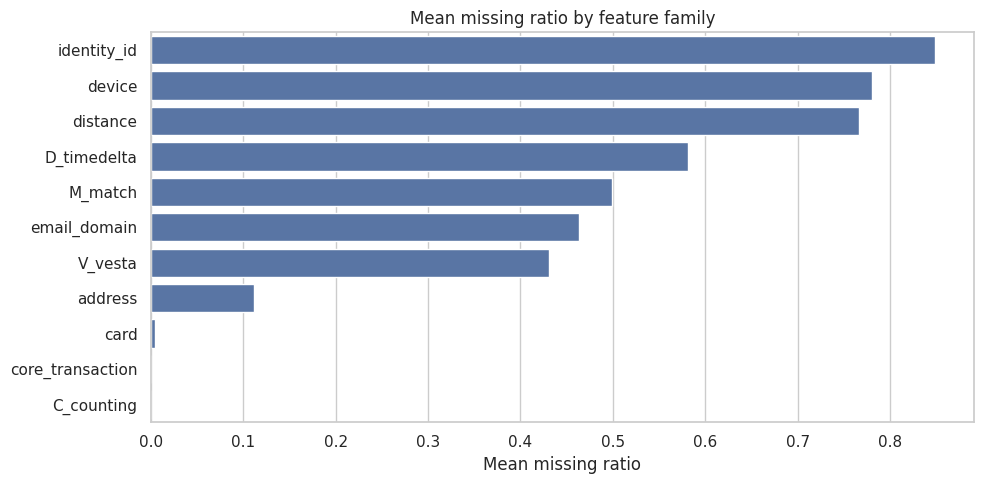

In [7]:
def startswith_any(col: str, prefixes: tuple[str, ...]) -> bool:
    return any(col.startswith(prefix) for prefix in prefixes)

feature_families = {
    "core_transaction": ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD"],
    "card": [col for col in joined.columns if col.startswith("card")],
    "address": [col for col in joined.columns if col.startswith("addr")],
    "distance": [col for col in joined.columns if col.startswith("dist")],
    "email_domain": [col for col in ["P_emaildomain", "R_emaildomain"] if col in joined.columns],
    "C_counting": [col for col in joined.columns if col.startswith("C") and col[1:].isdigit()],
    "D_timedelta": [col for col in joined.columns if col.startswith("D") and col[1:].isdigit()],
    "M_match": [col for col in joined.columns if col.startswith("M") and col[1:].isdigit()],
    "V_vesta": [col for col in joined.columns if col.startswith("V") and col[1:].isdigit()],
    "identity_id": [col for col in joined.columns if col.startswith("id_")],
    "device": [col for col in ["DeviceType", "DeviceInfo"] if col in joined.columns],
}

assigned = set(sum(feature_families.values(), []))
feature_families["other"] = [col for col in joined.columns if col not in assigned and col != "has_identity"]

family_rows = []
for family, cols in feature_families.items():
    present_cols = [col for col in cols if col in joined.columns]
    if not present_cols:
        continue
    family_rows.append({
        "family": family,
        "column_count": len(present_cols),
        "mean_missing_ratio": float(joined[present_cols].isna().mean().mean()),
        "median_missing_ratio": float(joined[present_cols].isna().mean().median()),
        "sample_columns": ", ".join(present_cols[:8]),
    })

feature_family_summary = pd.DataFrame(family_rows).sort_values("column_count", ascending=False)
feature_family_summary.to_csv(EDA_RESULTS_DIR / "feature_family_summary.csv", index=False)
display(feature_family_summary)

fig, ax = plt.subplots(figsize=(10, 5))
plot_family = feature_family_summary.sort_values("mean_missing_ratio", ascending=False)
sns.barplot(data=plot_family, x="mean_missing_ratio", y="family", ax=ax)
ax.set_title("Mean missing ratio by feature family")
ax.set_xlabel("Mean missing ratio")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "missing_ratio_by_feature_family.png", dpi=150)
plt.show()

## 7. Family-level numeric summaries

**VI:** Các nhóm `C*`, `D*`, `V*` có nhiều numeric feature ẩn danh. Thay vì plot từng cột một cách rối, ta lấy overview theo family: missing, median, và correlation tuyệt đối trung bình với label. Đây chỉ là EDA mô tả, không phải feature selection cuối cùng.

**EN:** Masked numeric families such as `C*`, `D*`, and `V*` are summarized at family level to keep the EDA readable.

,family,numeric_columns,correlation_columns_used,mean_missing_ratio,median_missing_ratio,mean_abs_corr_with_label_sampled,max_abs_corr_with_label_sampled
6,identity_id,23,23,0.869979,0.873123,0.049583,0.174608
1,D_timedelta,15,15,0.581513,0.524674,0.066704,0.151096
3,card,4,4,0.006247,0.004931,0.049457,0.147081
2,V_vesta,339,40,0.430385,0.472935,0.020938,0.134129
5,distance,2,2,0.766404,0.766404,0.033881,0.035248
4,address,2,2,0.111264,0.111264,0.017541,0.034102
0,C_counting,14,14,0.000000,0.000000,0.021626,0.030239


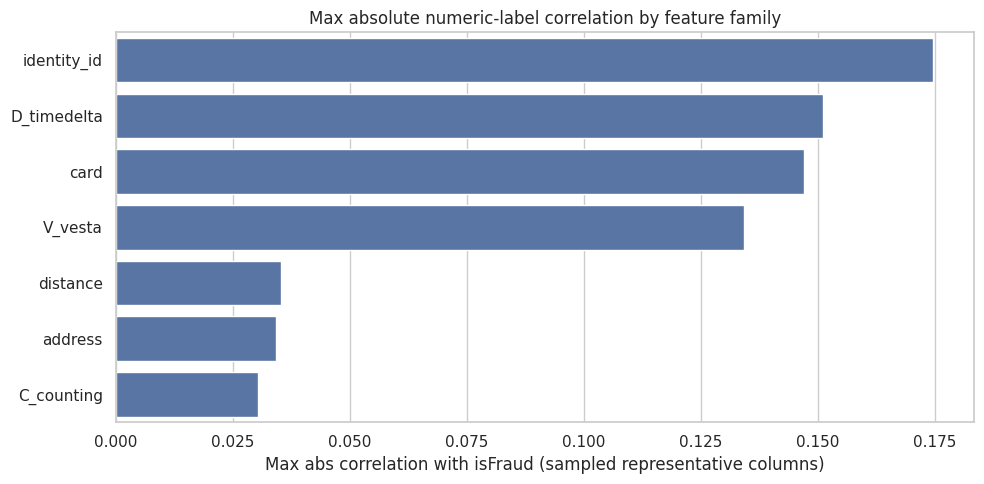

In [8]:
FAMILY_CORR_SAMPLE_ROWS = 20_000
MAX_NUMERIC_COLUMNS_PER_FAMILY = 40

family_numeric_rows = []
for family in ["C_counting", "D_timedelta", "V_vesta", "card", "address", "distance", "identity_id"]:
    cols = [col for col in feature_families.get(family, []) if col in joined.columns]
    numeric_family_cols = [col for col in cols if pd.api.types.is_numeric_dtype(joined[col])]
    if not numeric_family_cols:
        continue

    # Use representative columns with the highest non-missing coverage so this stays fast in Colab.
    coverage = joined[numeric_family_cols].notna().mean().sort_values(ascending=False)
    corr_cols = coverage.head(MAX_NUMERIC_COLUMNS_PER_FAMILY).index.tolist()
    corr_df = joined[corr_cols + [LABEL_COL]].dropna(axis=1, how="all")
    if len(corr_df) > FAMILY_CORR_SAMPLE_ROWS:
        corr_df = corr_df.sample(n=FAMILY_CORR_SAMPLE_ROWS, random_state=RANDOM_SEED)

    corrs = corr_df.corr(numeric_only=True)[LABEL_COL].drop(labels=[LABEL_COL], errors="ignore").dropna().abs()
    family_numeric_rows.append({
        "family": family,
        "numeric_columns": len(numeric_family_cols),
        "correlation_columns_used": len(corr_cols),
        "mean_missing_ratio": float(joined[numeric_family_cols].isna().mean().mean()),
        "median_missing_ratio": float(joined[numeric_family_cols].isna().mean().median()),
        "mean_abs_corr_with_label_sampled": float(corrs.mean()) if len(corrs) else np.nan,
        "max_abs_corr_with_label_sampled": float(corrs.max()) if len(corrs) else np.nan,
    })

family_numeric_summary = pd.DataFrame(family_numeric_rows).sort_values("max_abs_corr_with_label_sampled", ascending=False)
family_numeric_summary.to_csv(EDA_RESULTS_DIR / "family_numeric_summary.csv", index=False)
display(family_numeric_summary)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=family_numeric_summary, x="max_abs_corr_with_label_sampled", y="family", ax=ax)
ax.set_title("Max absolute numeric-label correlation by feature family")
ax.set_xlabel("Max abs correlation with isFraud (sampled representative columns)")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "family_numeric_label_correlation.png", dpi=150)
plt.show()

## 8. Target imbalance and approve-all warning

**VI:** Phần này cho thấy vì sao Accuracy không phù hợp. Với dữ liệu mất cân bằng, approve-all có Accuracy cao nhưng bỏ sót toàn bộ fraud.

**EN:** This shows why Accuracy is unsuitable. With imbalanced data, approve-all can have high Accuracy while missing all fraud.

,isFraud,count,ratio,label
0,0,569877,0.96501,legitimate
1,1,20663,0.03499,fraud


Approve-all Accuracy: 96.5010%
Approve-all fraud recall: 0.0000%
=> Accuracy is not the main metric because this policy misses every fraud transaction.


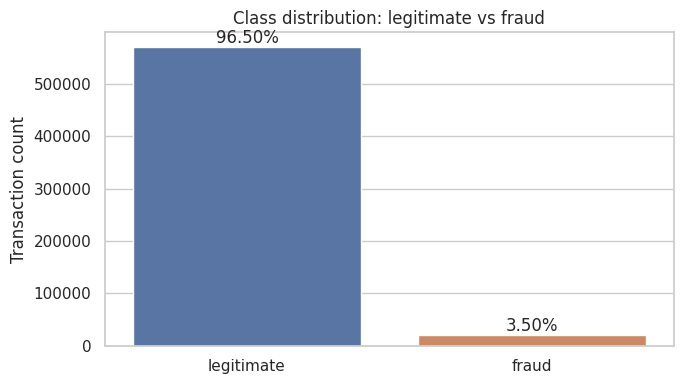

In [9]:
class_counts = joined[LABEL_COL].value_counts().sort_index().rename_axis("isFraud").reset_index(name="count")
class_counts["ratio"] = class_counts["count"] / len(joined)
class_counts["label"] = class_counts["isFraud"].map({0: "legitimate", 1: "fraud"})
class_counts.to_csv(EDA_RESULTS_DIR / "class_distribution.csv", index=False)

display(class_counts)

approve_all_accuracy = float((joined[LABEL_COL] == 0).mean())
approve_all_recall_fraud = 0.0
print(f"Approve-all Accuracy: {approve_all_accuracy:.4%}")
print(f"Approve-all fraud recall: {approve_all_recall_fraud:.4%}")
print("=> Accuracy is not the main metric because this policy misses every fraud transaction.")

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_counts, x="label", y="count", hue="label", ax=ax, legend=False)
ax.set_title("Class distribution: legitimate vs fraud")
ax.set_xlabel("")
ax.set_ylabel("Transaction count")
for idx, row in class_counts.iterrows():
    ax.text(idx, row["count"], f"{row['ratio']:.2%}", ha="center", va="bottom")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "class_distribution_with_rate.png", dpi=150)
plt.show()

## 9. TransactionAmt distribution by label

**VI:** Reward/cost sau này phụ thuộc `TransactionAmt`, nên EDA phải xem amount theo fraud vs legitimate, không chỉ đếm class.

**EN:** Later cost/reward functions depend on `TransactionAmt`, so EDA must inspect amount by fraud label.

,isFraud,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,label
0,0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,267.112,435.0,1104.0,31937.391,legitimate
1,1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,335.000,500.0,994.0,5191.000,fraud


Plotting amount distribution on 50,000 sampled rows; summary table above uses full data.


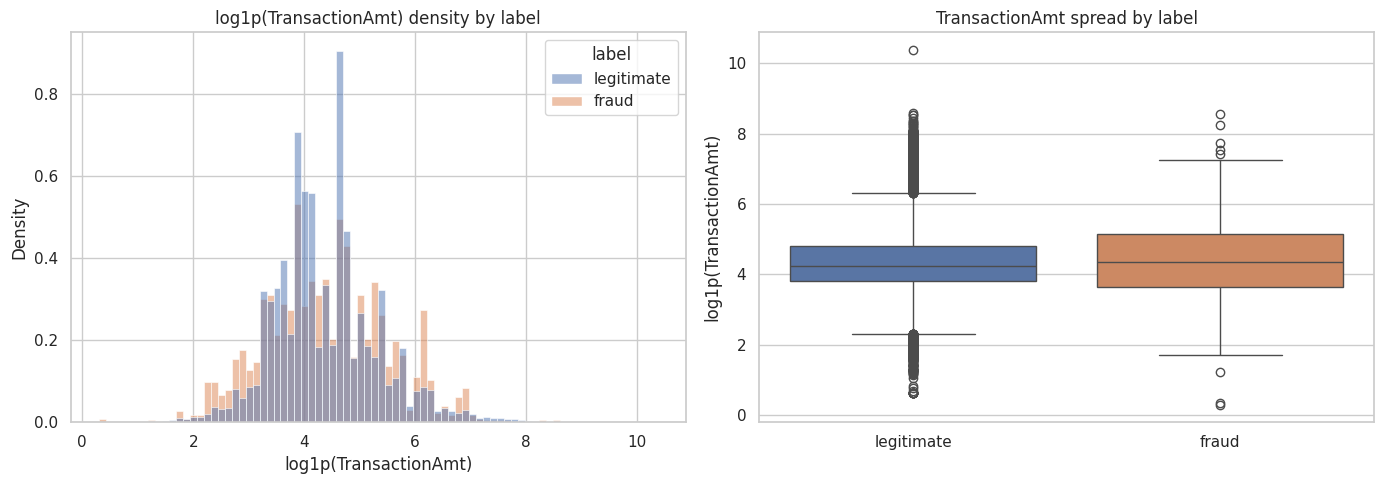

In [10]:
amount_summary = (
    joined.groupby(LABEL_COL)[AMOUNT_COL]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)
amount_summary["label"] = amount_summary[LABEL_COL].map({0: "legitimate", 1: "fraud"})
amount_summary.to_csv(EDA_RESULTS_DIR / "transaction_amount_summary_by_label.csv", index=False)
display(amount_summary)

plot_df = joined[[AMOUNT_COL, LABEL_COL]].dropna().copy()
plot_df = sample_for_plot(plot_df)
print(f"Plotting amount distribution on {len(plot_df):,} sampled rows; summary table above uses full data.")
plot_df["label"] = plot_df[LABEL_COL].map({0: "legitimate", 1: "fraud"})
plot_df["log1p_amount"] = np.log1p(plot_df[AMOUNT_COL].clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=plot_df, x="log1p_amount", hue="label", bins=80, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("log1p(TransactionAmt) density by label")
axes[0].set_xlabel("log1p(TransactionAmt)")

sns.boxplot(data=plot_df, x="label", y="log1p_amount", hue="label", ax=axes[1], legend=False)
axes[1].set_title("TransactionAmt spread by label")
axes[1].set_xlabel("")
axes[1].set_ylabel("log1p(TransactionAmt)")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "amount_distribution_by_label.png", dpi=150)
plt.show()

## 10. Missingness analysis

**VI:** IEEE-CIS có nhiều missing value, đặc biệt sau khi join identity. Phần này tách missing theo source transaction/identity để giải thích rõ trong báo cáo.

**EN:** IEEE-CIS has many missing values, especially after the identity join. This separates missingness by source table.

,column,missing_ratio,source,missing_count
0,id_24,0.991962,identity,585793
1,id_25,0.991310,identity,585408
2,id_07,0.991271,identity,585385
3,id_08,0.991271,identity,585385
4,id_21,0.991264,identity,585381
5,id_26,0.991257,identity,585377
6,id_27,0.991247,identity,585371
7,id_23,0.991247,identity,585371
8,id_22,0.991247,identity,585371
9,dist2,0.936284,transaction,552913


,source,column_count,mean_missing_ratio,median_missing_ratio
0,identity,40,0.844836,0.791728
1,transaction,395,0.409694,0.286126


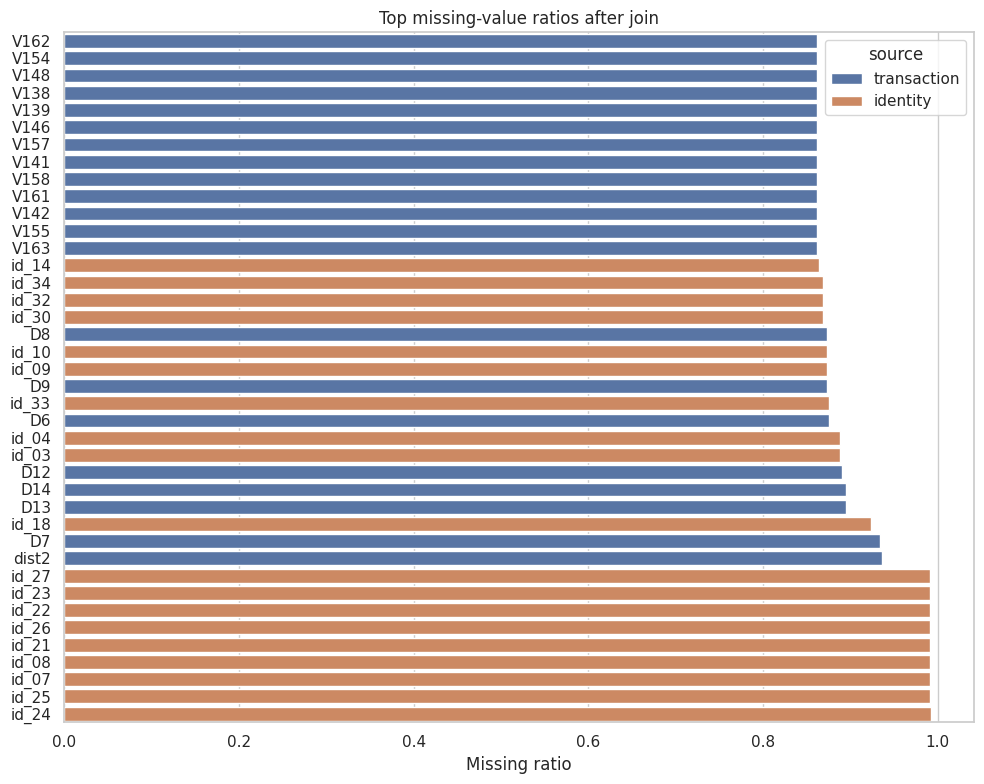

In [11]:
transaction_cols = set(transaction.columns)
identity_cols = set(identity.columns) - {ID_COL}

missing = joined.isna().mean().sort_values(ascending=False).reset_index()
missing.columns = ["column", "missing_ratio"]
missing["source"] = np.where(missing["column"].isin(identity_cols), "identity", "transaction")
missing["missing_count"] = (missing["missing_ratio"] * len(joined)).round().astype(int)
missing.to_csv(EDA_RESULTS_DIR / "missing_summary_all_columns.csv", index=False)

top_missing = missing.head(40)
display(top_missing)

missing_by_source = (
    missing.groupby("source")
    .agg(column_count=("column", "count"), mean_missing_ratio=("missing_ratio", "mean"), median_missing_ratio=("missing_ratio", "median"))
    .reset_index()
)
missing_by_source.to_csv(EDA_RESULTS_DIR / "missing_by_source.csv", index=False)
display(missing_by_source)

fig, ax = plt.subplots(figsize=(10, 8))
plot_missing = top_missing.sort_values("missing_ratio", ascending=True)
sns.barplot(data=plot_missing, y="column", x="missing_ratio", hue="source", dodge=False, ax=ax)
ax.set_title("Top missing-value ratios after join")
ax.set_xlabel("Missing ratio")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "top_missing_by_source.png", dpi=150)
plt.show()

## 11. Identity coverage by label

**VI:** Không phải giao dịch nào cũng có identity. Ta không drop các dòng này; thay vào đó báo cáo coverage và để missingness đi qua preprocessing.

**EN:** Not every transaction has identity data. We keep those rows and report coverage.

,isFraud,rows,identity_rows,identity_coverage_rate,missing_identity_rows,label
0,0,569877,132915,0.233235,436962,legitimate
1,1,20663,11318,0.547742,9345,fraud


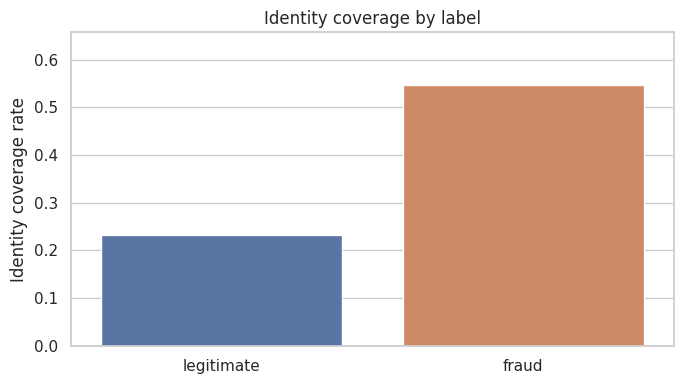

In [12]:
identity_coverage_by_label = (
    joined.groupby(LABEL_COL)["has_identity"]
    .agg(rows="count", identity_rows="sum", identity_coverage_rate="mean")
    .reset_index()
)
identity_coverage_by_label["missing_identity_rows"] = identity_coverage_by_label["rows"] - identity_coverage_by_label["identity_rows"]
identity_coverage_by_label["label"] = identity_coverage_by_label[LABEL_COL].map({0: "legitimate", 1: "fraud"})
identity_coverage_by_label.to_csv(EDA_RESULTS_DIR / "identity_coverage_by_label.csv", index=False)
display(identity_coverage_by_label)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=identity_coverage_by_label, x="label", y="identity_coverage_rate", hue="label", legend=False, ax=ax)
ax.set_title("Identity coverage by label")
ax.set_xlabel("")
ax.set_ylabel("Identity coverage rate")
ax.set_ylim(0, max(0.05, identity_coverage_by_label["identity_coverage_rate"].max() * 1.2))
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "identity_coverage_by_label.png", dpi=150)
plt.show()

## 12. Time-based behavior and split sanity

**VI:** Main split theo `TransactionDT`. Phần này kiểm tra fraud rate theo split và theo time bins để xem class imbalance có ổn định không.

**EN:** The main split uses `TransactionDT`. This checks fraud rate by split and time bins.

,split,rows,fraud_count,legitimate_count,fraud_rate,min_transaction_dt,max_transaction_dt
0,train,413378,14538,398840,0.035169,86400,10437996
1,validation,88581,3042,85539,0.034341,10438003,13151840
2,test,88581,3083,85498,0.034804,13151880,15811131


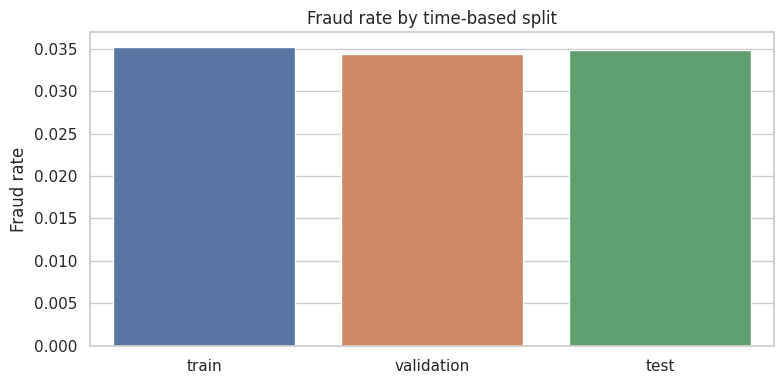

,time_bin,rows,fraud_count,min_dt,max_dt,fraud_rate,bin_index
0,"(86399.999, 512906.867]",19685,544,86400,512898,0.027635,0
1,"(512906.867, 956924.267]",19685,576,512912,956912,0.029261,1
2,"(956924.267, 1361004.4]",19684,511,956958,1360999,0.025960,2
3,"(1361004.4, 1712406.533]",19685,469,1361005,1712406,0.023825,3
4,"(1712406.533, 1985511.333]",19685,429,1712407,1985511,0.021793,4


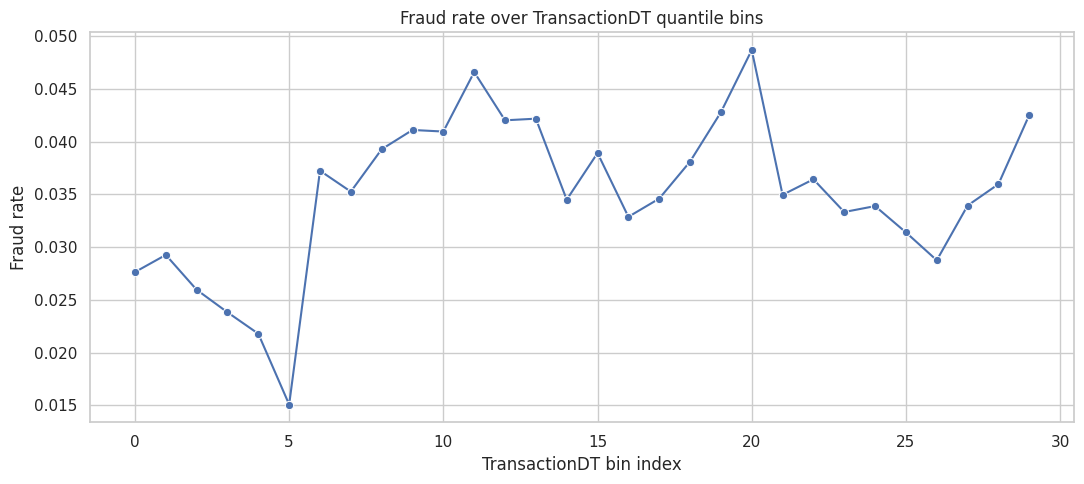

In [13]:
split_summary = outputs["split_summary"].copy()
split_summary.to_csv(EDA_RESULTS_DIR / "fraud_rate_by_split.csv", index=False)
display(split_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=split_summary, x="split", y="fraud_rate", hue="split", legend=False, ax=ax)
ax.set_title("Fraud rate by time-based split")
ax.set_xlabel("")
ax.set_ylabel("Fraud rate")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "fraud_rate_by_split.png", dpi=150)
plt.show()

# Quantile bins keep roughly comparable support per time segment.
time_bins = joined[[TIME_COL, LABEL_COL]].dropna().copy()
time_bins["time_bin"] = pd.qcut(time_bins[TIME_COL], q=30, duplicates="drop")
time_profile = (
    time_bins.groupby("time_bin", observed=True)
    .agg(rows=(LABEL_COL, "size"), fraud_count=(LABEL_COL, "sum"), min_dt=(TIME_COL, "min"), max_dt=(TIME_COL, "max"))
    .reset_index()
)
time_profile["fraud_rate"] = time_profile["fraud_count"] / time_profile["rows"]
time_profile["bin_index"] = range(len(time_profile))
time_profile.to_csv(EDA_RESULTS_DIR / "fraud_rate_by_transactiondt_bin.csv", index=False)
display(time_profile.head())

fig, ax1 = plt.subplots(figsize=(11, 5))
sns.lineplot(data=time_profile, x="bin_index", y="fraud_rate", marker="o", ax=ax1)
ax1.set_title("Fraud rate over TransactionDT quantile bins")
ax1.set_xlabel("TransactionDT bin index")
ax1.set_ylabel("Fraud rate")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "fraud_rate_over_time_bins.png", dpi=150)
plt.show()

## 13. Categorical feature summaries

**VI:** Phần này xem các cột categorical quan trọng nếu tồn tại. Không diễn giải `ProductCD` thành loại hàng; chỉ xem nó như mã categorical đúng theo dataset.

**EN:** This profiles selected categorical columns if present. `ProductCD` is treated only as a dataset code, not interpreted as a product category.

Available categorical columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'id_30', 'id_31', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6']

ProductCD - top values by fraud rate with support >= 100


,ProductCD,rows,fraud_count,fraud_rate
0,C,68519,8008,0.116873
3,S,11628,686,0.058996
1,H,33024,1574,0.047662
2,R,37699,1426,0.037826
4,W,439670,8969,0.020399



card4 - top values by fraud rate with support >= 100


,card4,rows,fraud_count,fraud_rate
1,discover,6651,514,0.077282
4,visa,384767,13373,0.034756
2,mastercard,189217,6496,0.034331
0,american express,8328,239,0.028698
3,missing,1577,41,0.025999



card6 - top values by fraud rate with support >= 100


...

,M4,rows,fraud_count,fraud_rate
2,M2,59865,6809,0.113739
0,M0,196405,7198,0.036649
1,M1,52826,1429,0.027051
3,missing,281444,5227,0.018572



M5 - top values by fraud rate with support >= 100


,M5,rows,fraud_count,fraud_rate
1,T,107567,4055,0.037697
2,missing,350482,13094,0.037360
0,F,132491,3514,0.026523



M6 - top values by fraud rate with support >= 100


,M6,rows,fraud_count,fraud_rate
2,missing,169360,11971,0.070684
0,F,227856,5397,0.023686
1,T,193324,3295,0.017044


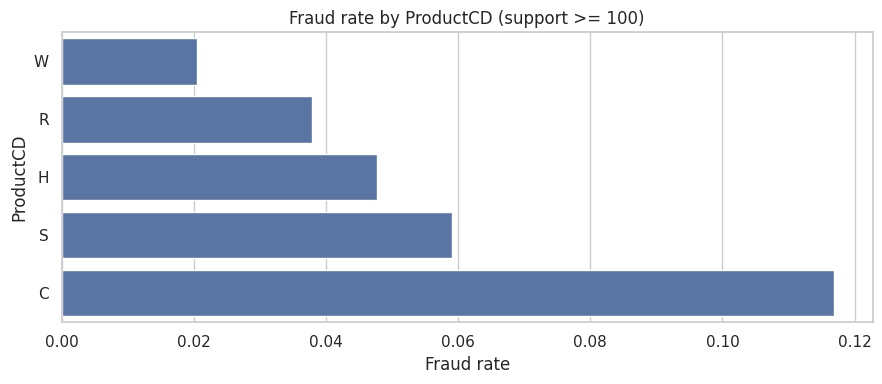

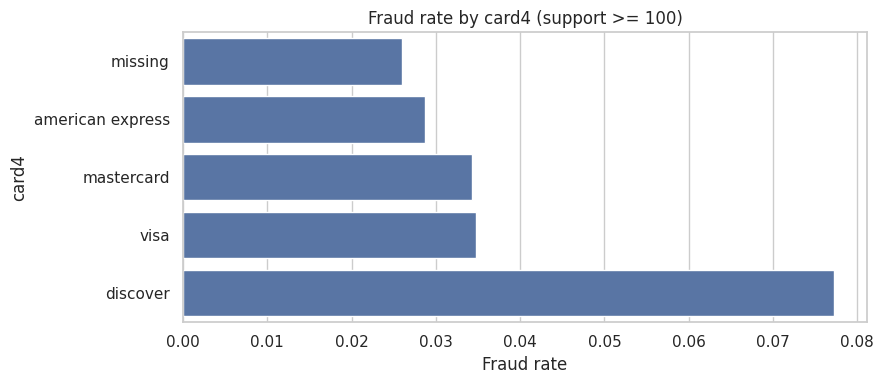

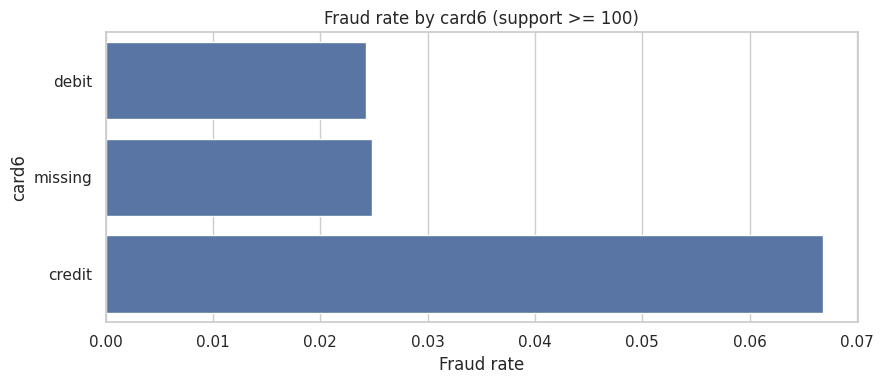

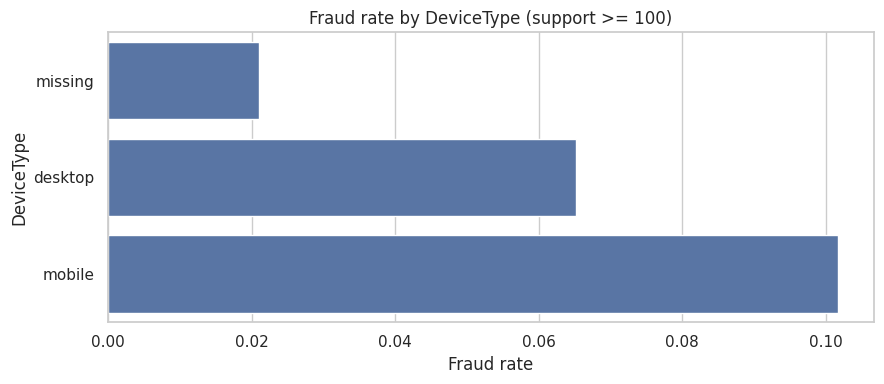

In [14]:
candidate_categoricals = [
    "ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain",
    "DeviceType", "DeviceInfo", "id_30", "id_31", "M1", "M2", "M3", "M4", "M5", "M6",
]
available_categoricals = [col for col in candidate_categoricals if col in joined.columns]
print("Available categorical columns:", available_categoricals)


def categorical_profile(df: pd.DataFrame, col: str, min_count: int = 100, top_n: int = 20) -> pd.DataFrame:
    profile = (
        df.assign(_value=df[col].astype("object").where(df[col].notna(), "missing"))
        .groupby("_value")[LABEL_COL]
        .agg(rows="count", fraud_count="sum", fraud_rate="mean")
        .reset_index()
        .rename(columns={"_value": col})
    )
    profile = profile[profile["rows"] >= min_count].sort_values(["fraud_rate", "rows"], ascending=[False, False])
    return profile.head(top_n)

for col in available_categoricals:
    profile = categorical_profile(joined, col)
    output_path = EDA_RESULTS_DIR / f"categorical_profile_{col}.csv"
    profile.to_csv(output_path, index=False)
    print()
    print(f"{col} - top values by fraud rate with support >= 100")
    display(profile)

# Compact chart for a few stable, report-friendly columns.
chart_cols = [col for col in ["ProductCD", "card4", "card6", "DeviceType"] if col in available_categoricals]
for col in chart_cols:
    profile = categorical_profile(joined, col, min_count=100, top_n=12).sort_values("fraud_rate")
    fig, ax = plt.subplots(figsize=(9, max(4, len(profile) * 0.35)))
    sns.barplot(data=profile, y=col, x="fraud_rate", ax=ax)
    ax.set_title(f"Fraud rate by {col} (support >= 100)")
    ax.set_xlabel("Fraud rate")
    ax.set_ylabel(col)
    fig.tight_layout()
    fig.savefig(EDA_FIGURES_DIR / f"fraud_rate_by_{col}.png", dpi=150)
    plt.show()

## 14. Numeric feature association with label

**VI:** Đây không phải feature selection cuối cùng. Nó chỉ là EDA để biết nhóm numeric nào có quan hệ tuyến tính mạnh hơn với label, phục vụ phần mô tả dữ liệu.

**EN:** This is not final feature selection. It is only EDA for understanding numeric-label association.

Computing numeric-label correlation on 50,000 sampled rows.


,feature,pearson_corr_with_isFraud,abs_corr
0,V257,0.374249,0.374249
1,V246,0.359296,0.359296
2,V244,0.345097,0.345097
3,V242,0.342966,0.342966
4,V201,0.323567,0.323567
5,V158,0.313141,0.313141
6,V149,0.307625,0.307625
7,V156,0.306064,0.306064
8,V258,0.305055,0.305055
9,V200,0.303986,0.303986


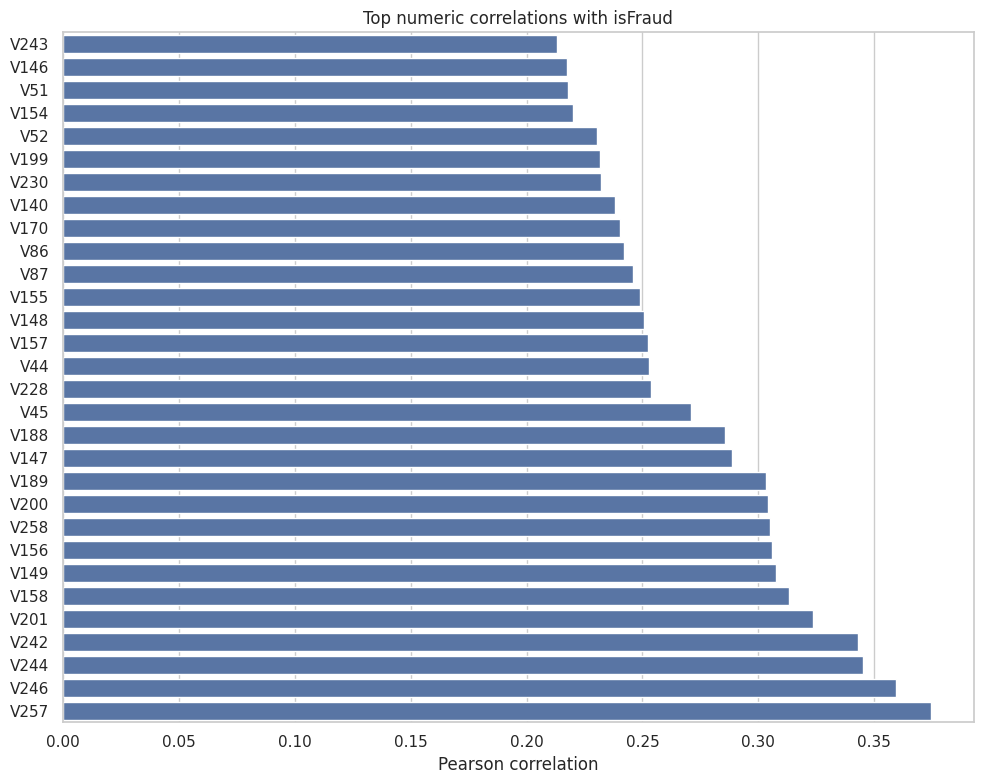

In [15]:
numeric_cols = joined.select_dtypes(include=["number", "bool"]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in [LABEL_COL, ID_COL]]

# Use a fixed sample for speed; this EDA association is descriptive, not final feature selection.
corr_df = sample_for_plot(joined[numeric_cols + [LABEL_COL]])
print(f"Computing numeric-label correlation on {len(corr_df):,} sampled rows.")
numeric_corr = corr_df.corr(numeric_only=True)[LABEL_COL].drop(labels=[LABEL_COL], errors="ignore")
numeric_corr = numeric_corr.dropna().sort_values(key=lambda s: s.abs(), ascending=False).head(30)
numeric_corr_table = numeric_corr.rename("pearson_corr_with_isFraud").reset_index().rename(columns={"index": "feature"})
numeric_corr_table["abs_corr"] = numeric_corr_table["pearson_corr_with_isFraud"].abs()
numeric_corr_table.to_csv(EDA_RESULTS_DIR / "numeric_label_correlation_top30.csv", index=False)
display(numeric_corr_table)

fig, ax = plt.subplots(figsize=(10, 8))
plot_corr = numeric_corr_table.sort_values("abs_corr", ascending=True)
sns.barplot(data=plot_corr, y="feature", x="pearson_corr_with_isFraud", ax=ax)
ax.set_title("Top numeric correlations with isFraud")
ax.set_xlabel("Pearson correlation")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig(EDA_FIGURES_DIR / "numeric_label_correlation_top30.png", dpi=150)
plt.show()

## 15. Display saved report figures

**VI:** Hiển thị lại các hình đã lưu để notebook có output trực tiếp và file có thể đưa vào báo cáo.

**EN:** Display saved figures so the notebook has visible outputs and report-ready files.

reports/figures/class_distribution.png


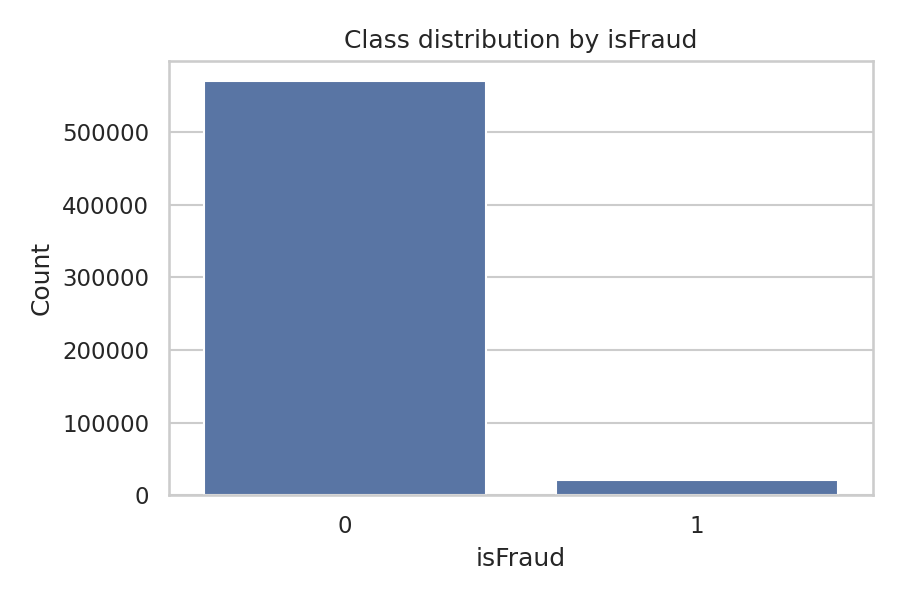

reports/figures/transaction_amount_distribution.png


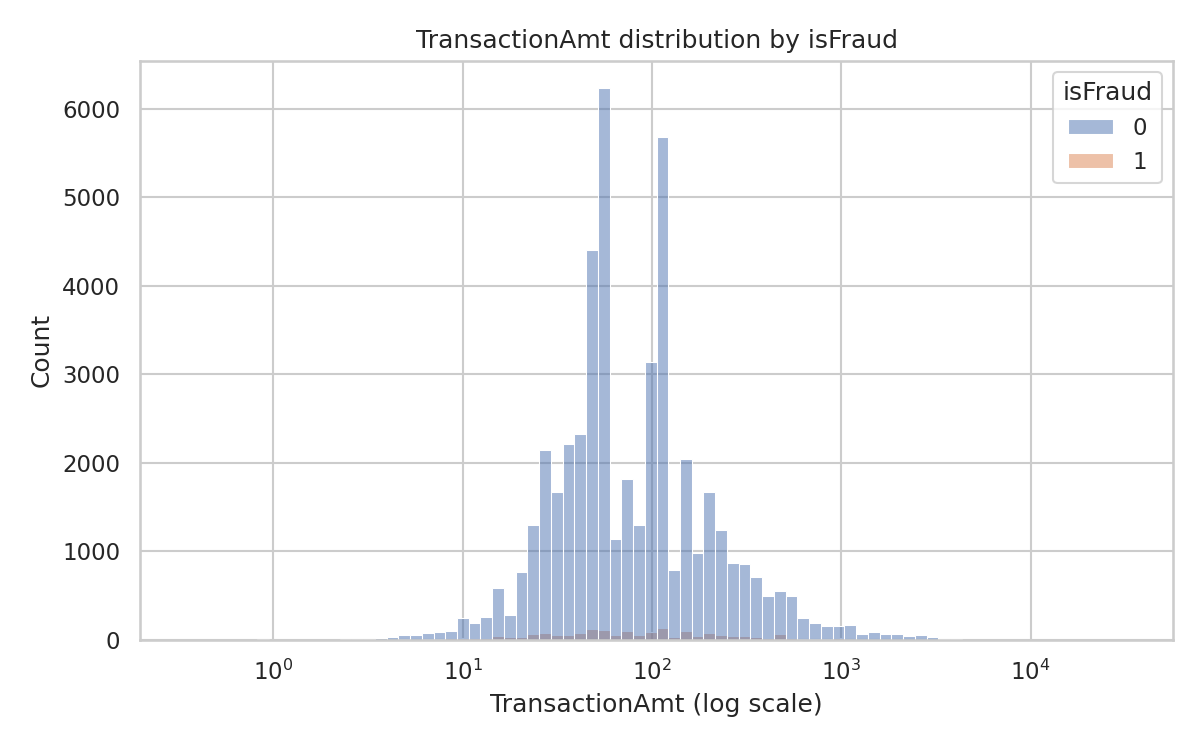

reports/figures/missing_values_top30.png


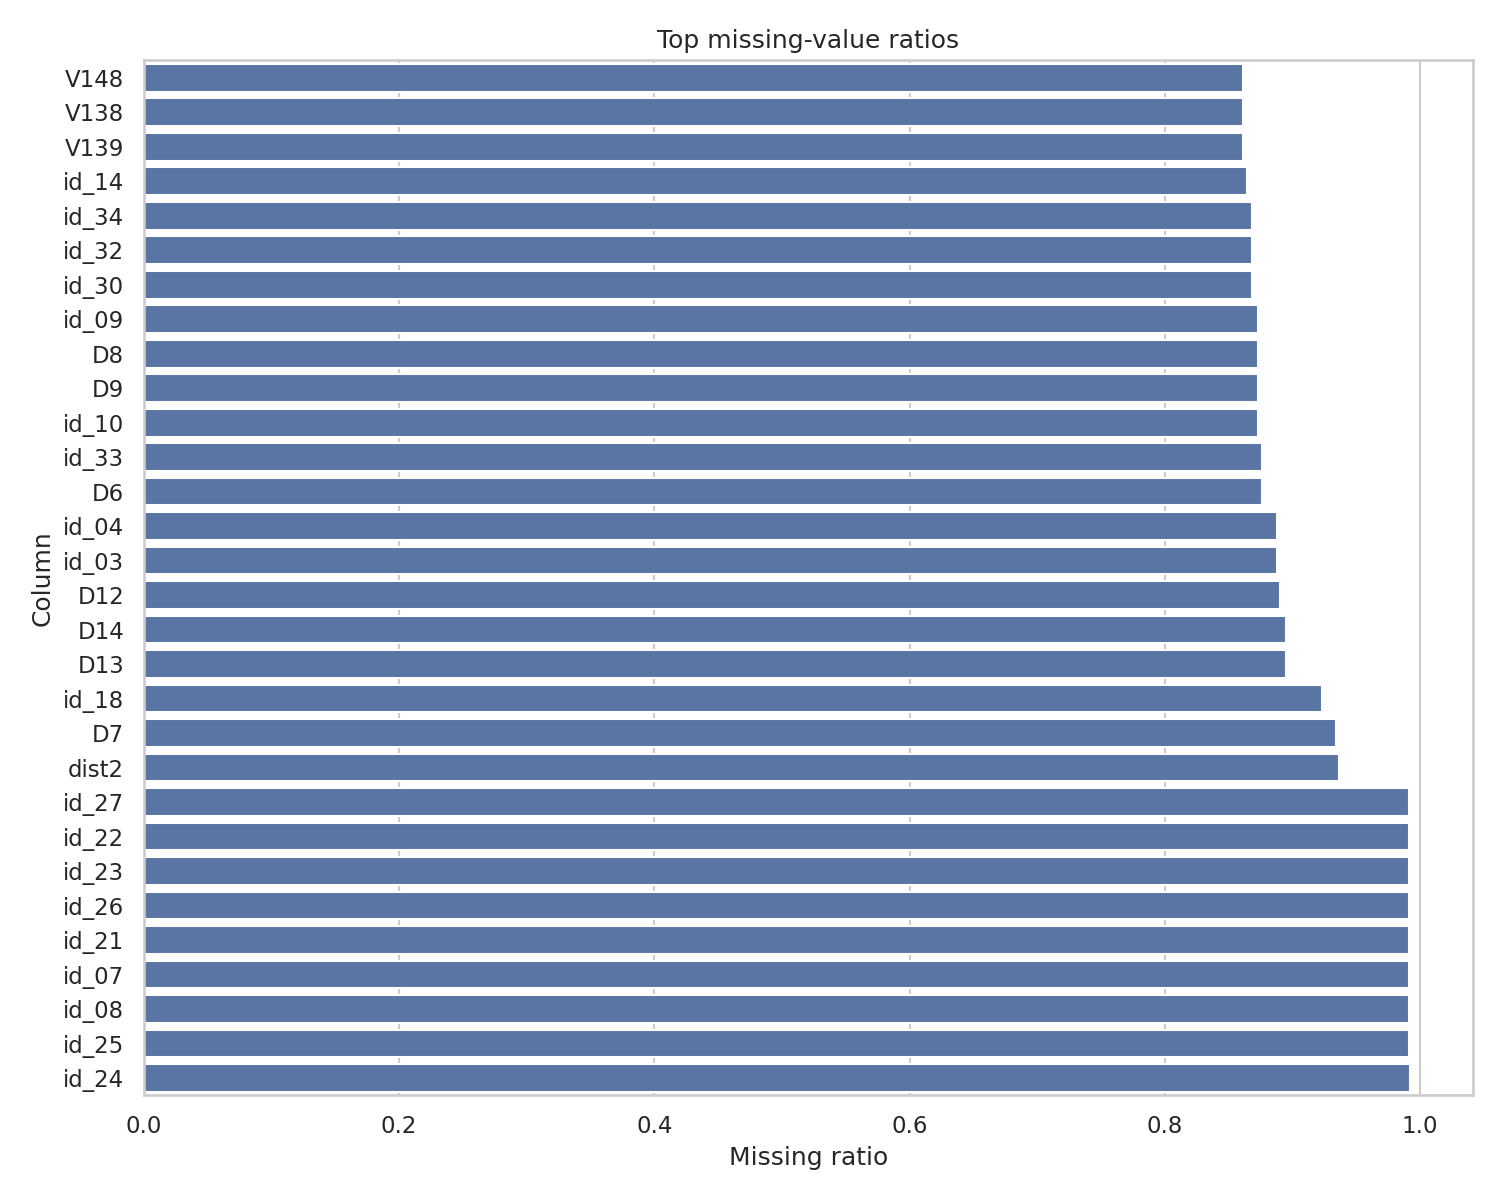

reports/figures/eda/class_distribution_with_rate.png


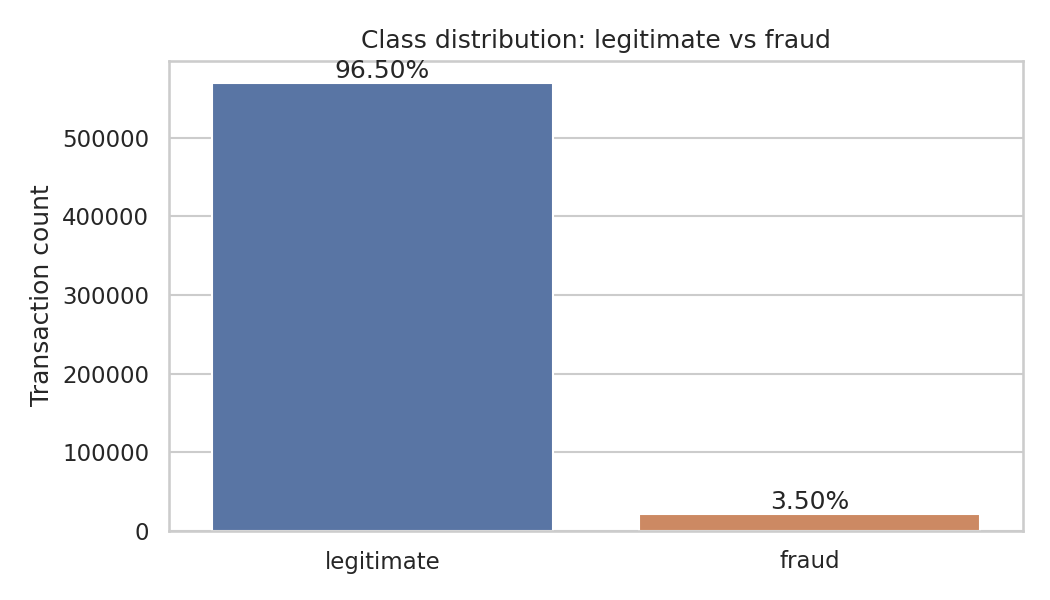

reports/figures/eda/amount_distribution_by_label.png


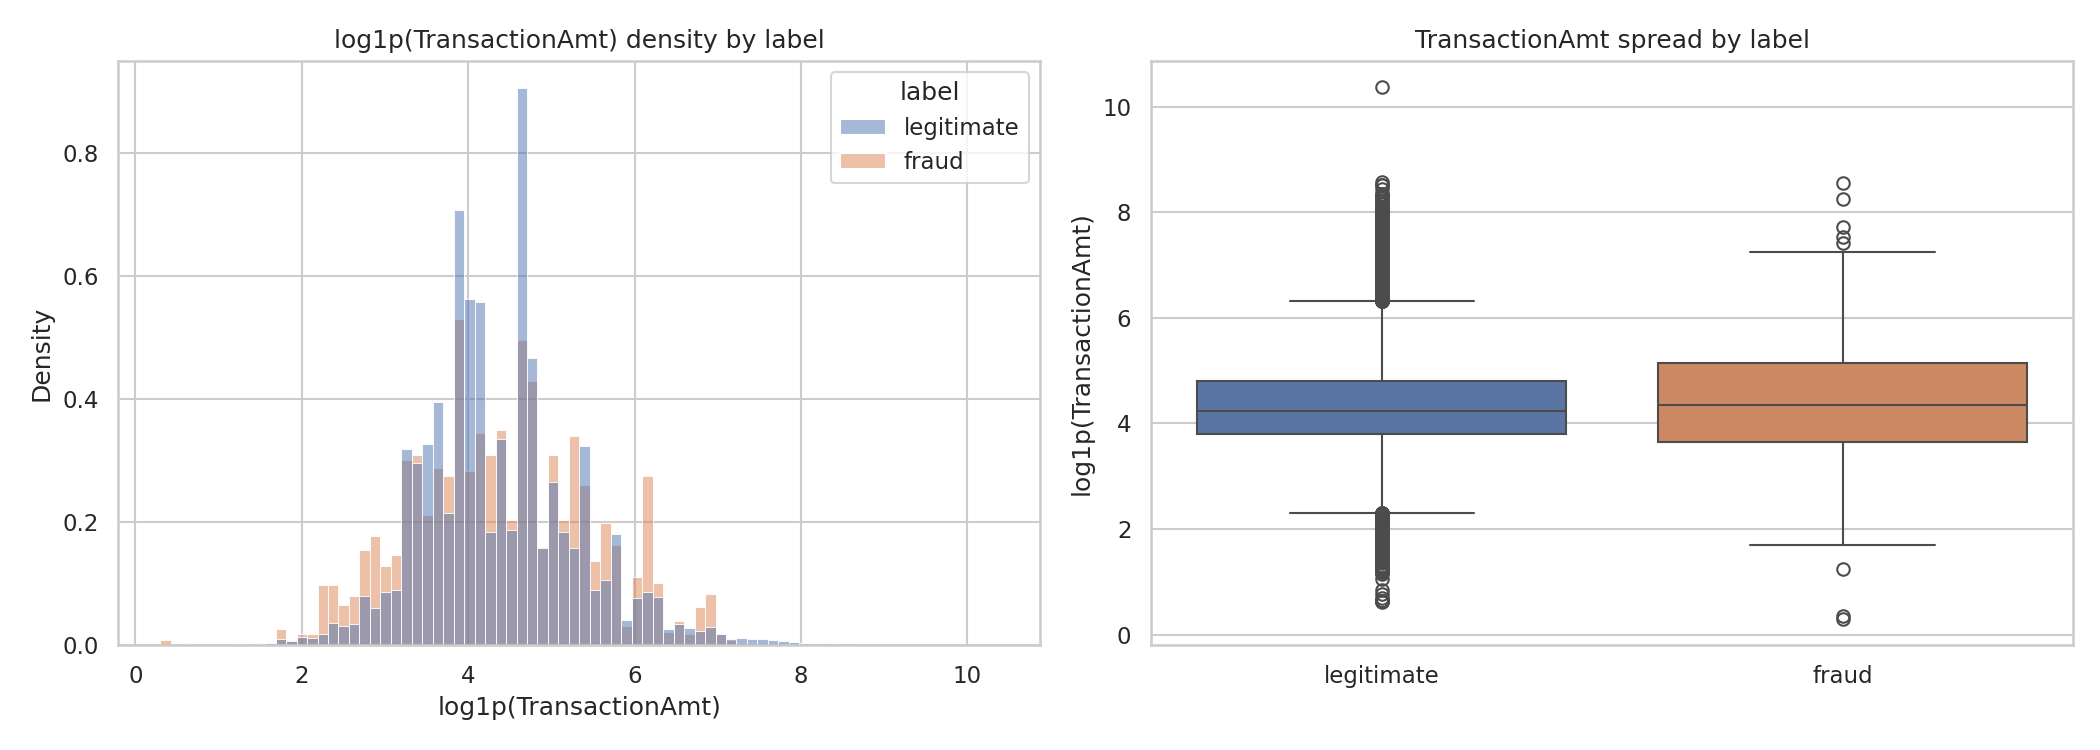

reports/figures/eda/top_missing_by_source.png


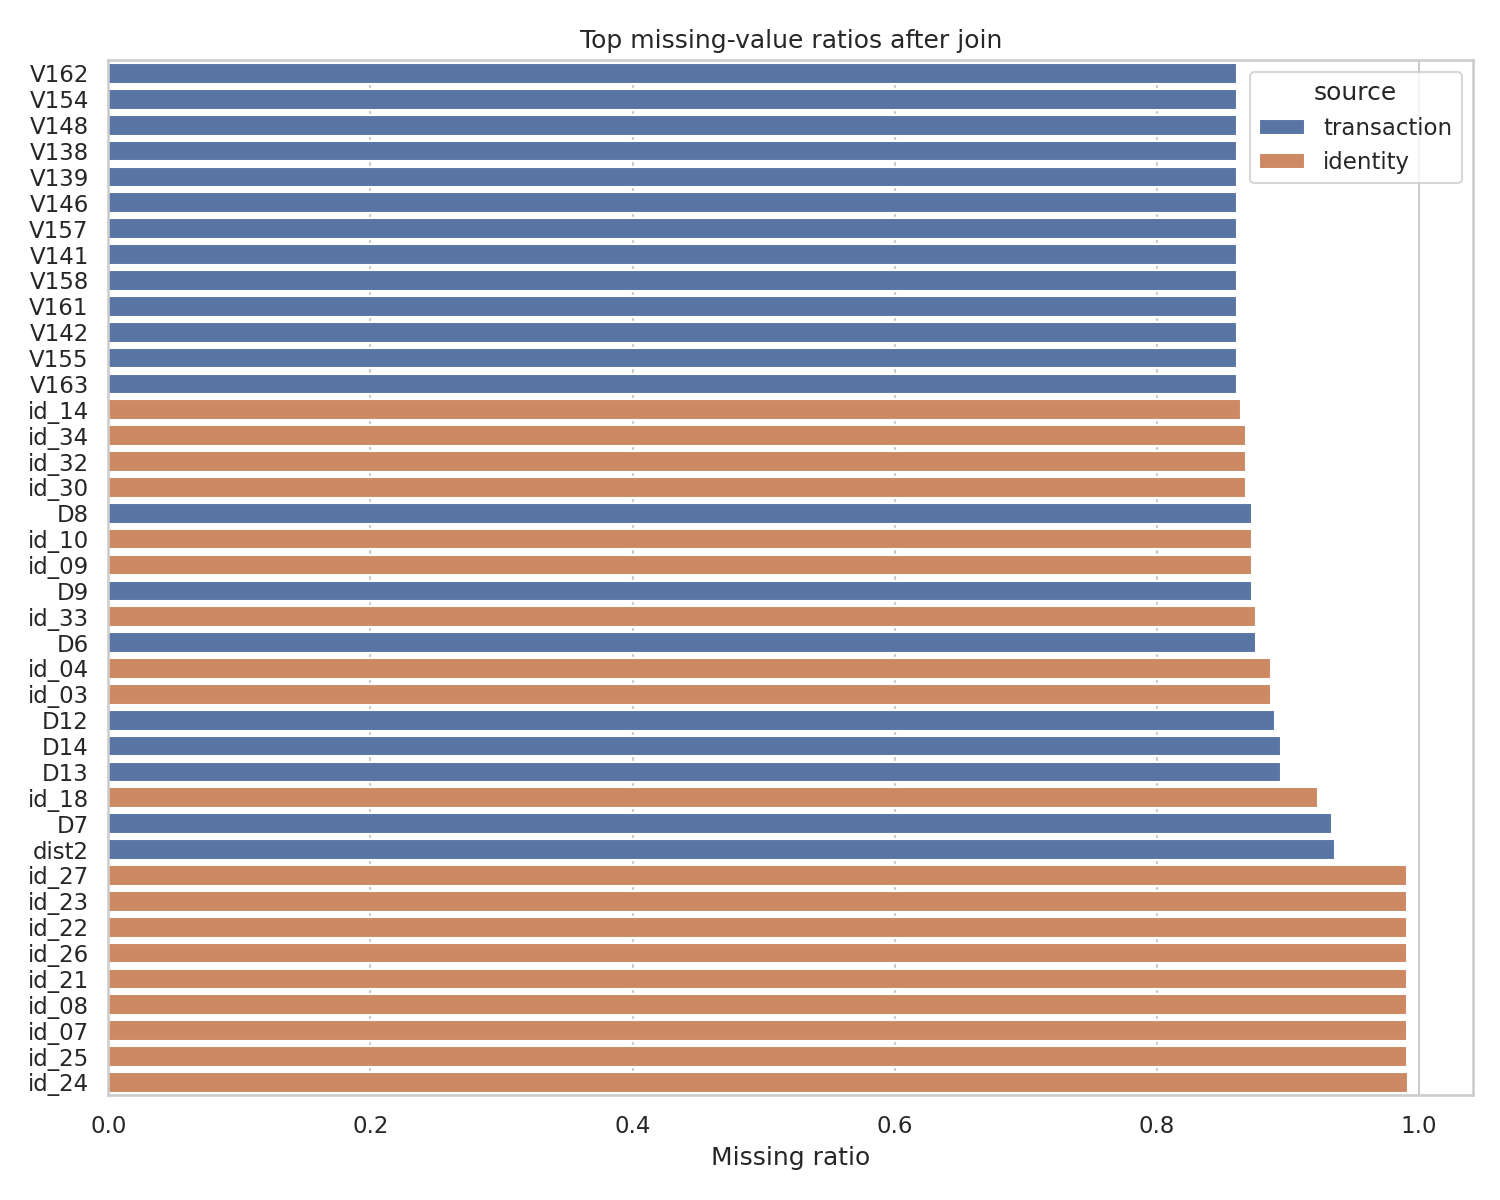

reports/figures/eda/identity_coverage_by_label.png


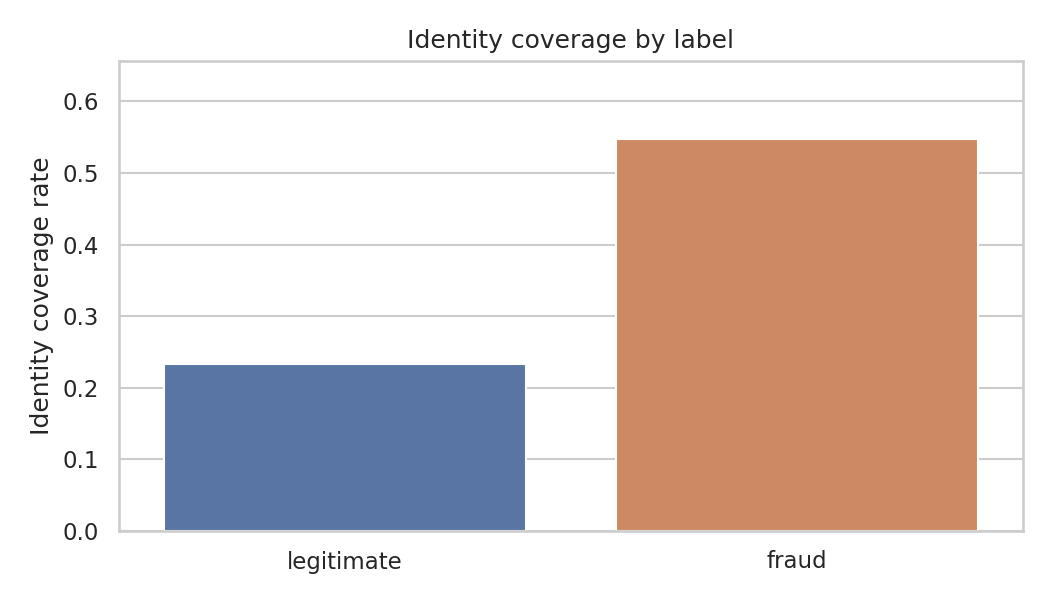

reports/figures/eda/fraud_rate_by_split.png


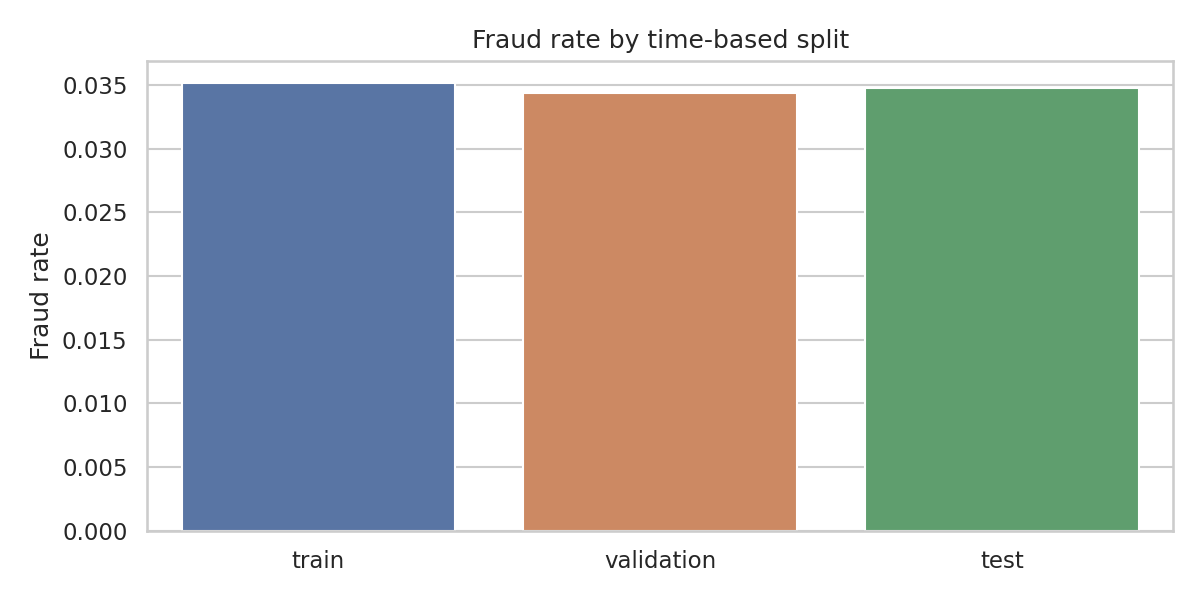

reports/figures/eda/fraud_rate_over_time_bins.png


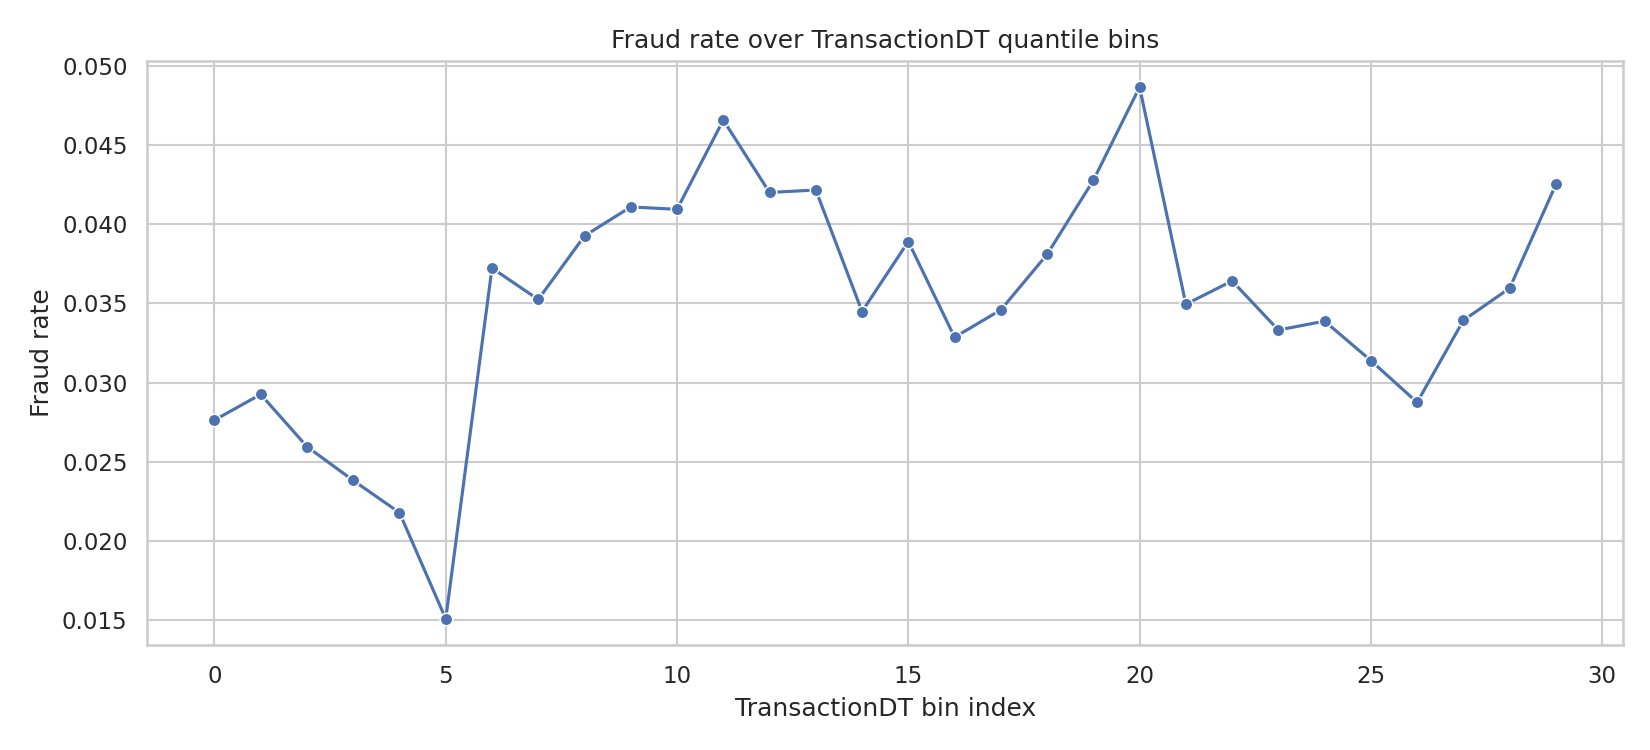

reports/figures/eda/numeric_label_correlation_top30.png


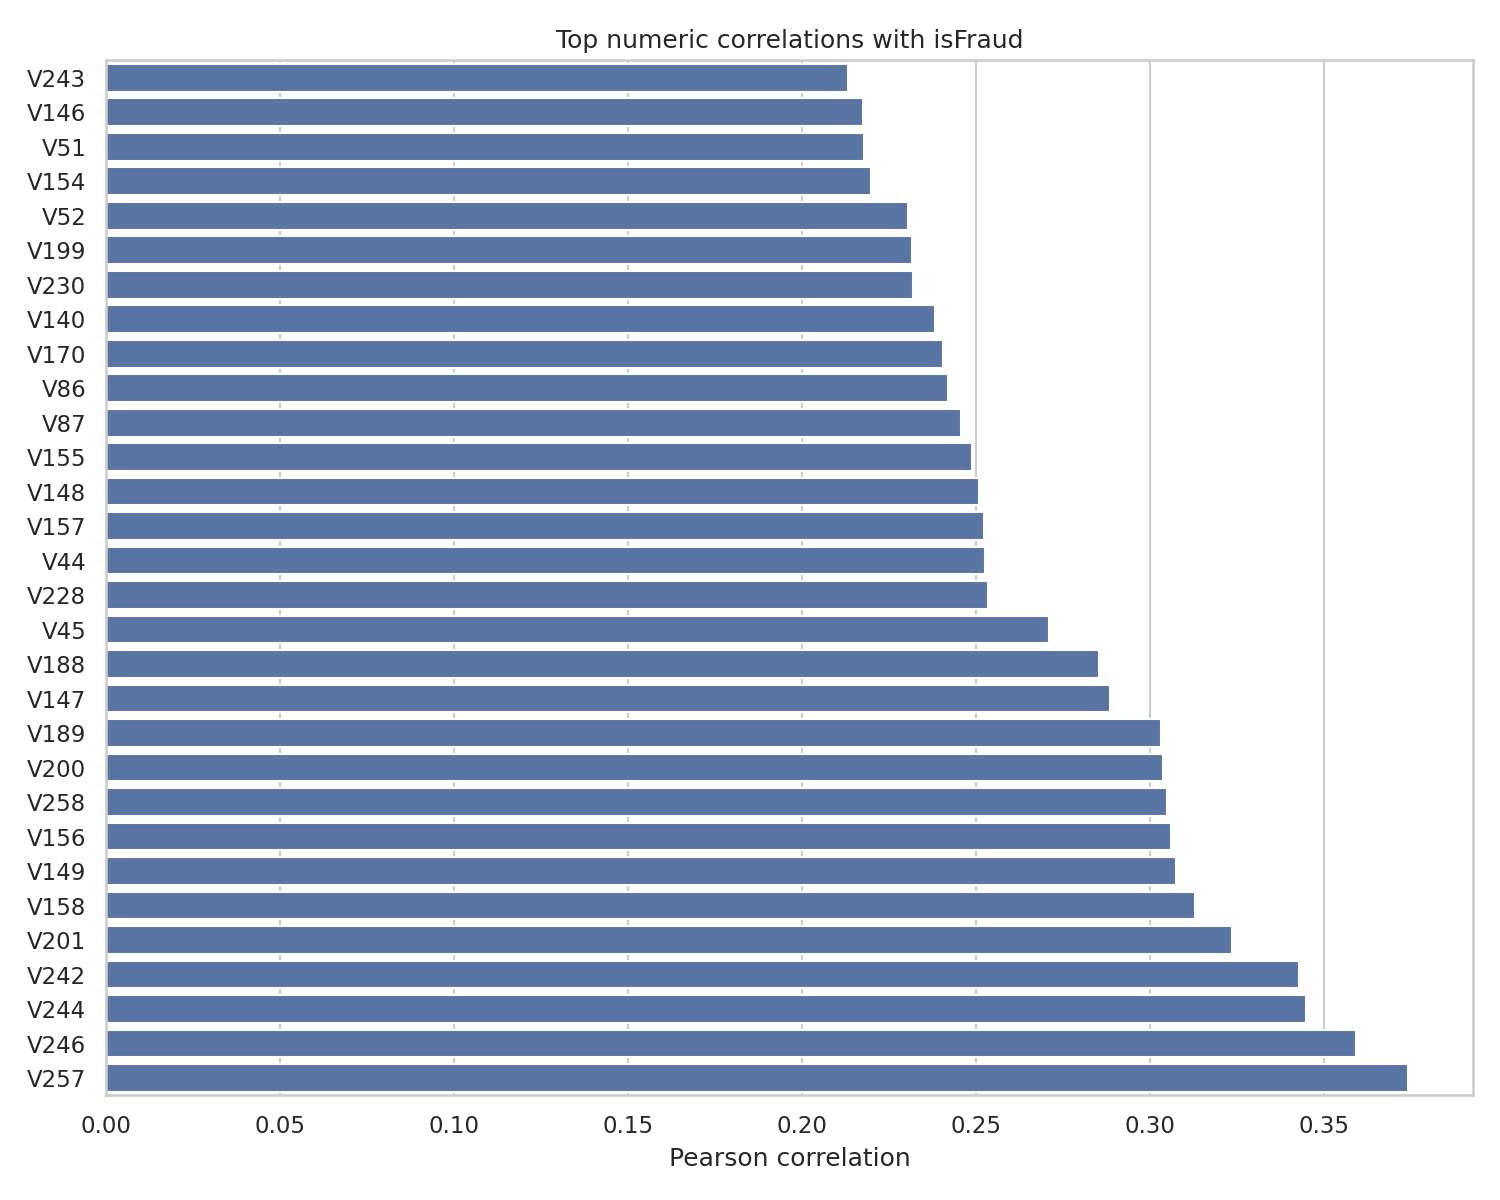

In [16]:
from IPython.display import Image, display

figure_paths = [
    FIGURES_DIR / "class_distribution.png",
    FIGURES_DIR / "transaction_amount_distribution.png",
    FIGURES_DIR / "missing_values_top30.png",
    EDA_FIGURES_DIR / "class_distribution_with_rate.png",
    EDA_FIGURES_DIR / "amount_distribution_by_label.png",
    EDA_FIGURES_DIR / "top_missing_by_source.png",
    EDA_FIGURES_DIR / "identity_coverage_by_label.png",
    EDA_FIGURES_DIR / "fraud_rate_by_split.png",
    EDA_FIGURES_DIR / "fraud_rate_over_time_bins.png",
    EDA_FIGURES_DIR / "numeric_label_correlation_top30.png",
]

for path in figure_paths:
    print(path.relative_to(PROJECT_ROOT))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print("Missing figure:", path)

## 16. Why Accuracy is not the main metric

**VI:** Với dữ liệu fraud mất cân bằng, approve-all có thể đạt Accuracy rất cao vì phần lớn giao dịch là legitimate. Nhưng policy này bỏ sót toàn bộ fraud, tạo False Negative Cost lớn. Vì vậy các phase sau phải dùng PR-AUC, Recall fraud, Precision fraud, F1 fraud, FN Cost, FP Cost, Total Cost và Cost Saving.

**EN:** With imbalanced fraud data, approve-all can achieve high Accuracy because most transactions are legitimate. But it misses all fraud and creates high False Negative Cost. Later phases therefore use PR-AUC, fraud Recall, fraud Precision, fraud F1, FN Cost, FP Cost, Total Cost, and Cost Saving.

## 17. First-pass preprocessing handoff

**VI:** Preprocessing đã có script riêng. Vì full one-hot artifact rất lớn, mặc định notebook không chạy lại preprocessing trừ khi cần tái tạo artifact. Phase 2 nên tránh regenerate full artifact liên tục.

**EN:** Preprocessing has its own script. Because the full one-hot artifact is large, the notebook does not rerun preprocessing by default unless artifact regeneration is needed.

In [17]:
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

PREPROCESS_LABEL_COL = "isFraud"
PREPROCESS_ID_COL = "TransactionID"
PREPROCESS_TIME_COL = "TransactionDT"
PRESERVE_COLS = (PREPROCESS_LABEL_COL, PREPROCESS_ID_COL, "TransactionAmt", "TransactionDT")
TIME_DERIVED_COLS = (
    "TransactionDT_elapsed_hour",
    "TransactionDT_elapsed_day",
    "TransactionDT_hour_bin",
)


def load_splits(processed_dir: Path) -> dict[str, pd.DataFrame]:
    required = {name: processed_dir / f"{name}.csv" for name in ("train", "validation", "test")}
    missing = [path for path in required.values() if not path.exists()]
    if missing:
        missing_text = "\n".join(f"- {path}" for path in missing)
        raise FileNotFoundError(
            "Processed split files are missing. Run the data pipeline cell first:\n"
            f"{missing_text}"
        )
    return {name: pd.read_csv(path, low_memory=False) for name, path in required.items()}


def feature_columns(df: pd.DataFrame) -> list[str]:
    return [col for col in df.columns if col not in (PREPROCESS_LABEL_COL, PREPROCESS_ID_COL)]


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create elapsed-time features without treating TransactionDT as a calendar date."""
    if PREPROCESS_TIME_COL not in df.columns:
        return df
    output = df.copy()
    transaction_dt = pd.to_numeric(output[PREPROCESS_TIME_COL], errors="coerce")
    output["TransactionDT_elapsed_hour"] = transaction_dt // 3600
    output["TransactionDT_elapsed_day"] = transaction_dt // 86400
    output["TransactionDT_hour_bin"] = (transaction_dt // 3600) % 24
    return output


def build_preprocessor(train_features: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    numeric_cols = train_features.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in train_features.columns if col not in numeric_cols]

    try:
        encoder = OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=True)
    except TypeError:
        try:
            encoder = OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse=True)
        except TypeError:
            encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("encoder", encoder),
        ]
    )
    transformer = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_cols),
            ("categorical", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
        sparse_threshold=0.3,
    )
    return transformer, numeric_cols, categorical_cols


def save_sparse_or_dense(matrix, path: Path) -> None:
    joblib.dump(matrix, path)


def run_preprocessing(
    processed_dir: str = "data/processed",
    artifacts_dir: str = "artifacts/preprocessing",
) -> dict[str, object]:
    processed_path = resolve_path(processed_dir)
    artifacts_path = resolve_path(artifacts_dir)
    artifacts_path.mkdir(parents=True, exist_ok=True)

    splits = load_splits(processed_path)
    splits = {split_name: add_time_features(split_df) for split_name, split_df in splits.items()}
    train = splits["train"]
    features = feature_columns(train)
    train_x = train[features]
    transformer, numeric_cols, categorical_cols = build_preprocessor(train_x)

    transformed = {"train": transformer.fit_transform(train_x)}
    for split_name in ("validation", "test"):
        transformed[split_name] = transformer.transform(splits[split_name][features])

    joblib.dump(transformer, artifacts_path / "preprocessor.joblib")
    for split_name, matrix in transformed.items():
        save_sparse_or_dense(matrix, artifacts_path / f"X_{split_name}.joblib")
        splits[split_name][[PREPROCESS_LABEL_COL]].to_csv(artifacts_path / f"y_{split_name}.csv", index=False)
        preserve = [col for col in PRESERVE_COLS if col in splits[split_name].columns]
        splits[split_name][preserve].to_csv(artifacts_path / f"meta_{split_name}.csv", index=False)

    metadata = pd.DataFrame(
        [
            {
                "train_rows": len(splits["train"]),
                "validation_rows": len(splits["validation"]),
                "test_rows": len(splits["test"]),
                "feature_count_before_encoding": len(features),
                "numeric_feature_count": len(numeric_cols),
                "categorical_feature_count": len(categorical_cols),
                "time_derived_feature_count": sum(col in features for col in TIME_DERIVED_COLS),
                "time_feature_policy": "derived from TransactionDT elapsed seconds; no real calendar date interpretation",
                "fit_policy": "preprocessor fit on train only; validation/test transformed only",
            }
        ]
    )
    metadata.to_csv(artifacts_path / "preprocessing_metadata.csv", index=False)
    return {
        "metadata": metadata,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "artifacts_dir": artifacts_path,
    }


RUN_PREPROCESSING = False  # Set True only when you need to regenerate artifacts.

if RUN_PREPROCESSING:
    preprocess_result = run_preprocessing(
        processed_dir="data/processed",
        artifacts_dir="artifacts/preprocessing",
    )
    display(preprocess_result["metadata"])
    print("Artifacts saved to:", preprocess_result["artifacts_dir"])
else:
    metadata_path = PROJECT_ROOT / "artifacts" / "preprocessing" / "preprocessing_metadata.csv"
    if metadata_path.exists():
        metadata = pd.read_csv(metadata_path)
        print("Existing preprocessing metadata")
        display(metadata)
    else:
        print("Preprocessing artifact not found. Set RUN_PREPROCESSING = True to generate it.")

Preprocessing artifact not found. Set RUN_PREPROCESSING = True to generate it.


## 18. End-to-end output checklist

**VI:** Kiểm tra nhanh các output chính của Phase 1 sau khi chạy notebook.

**EN:** Quick check for the main Phase 1 outputs.

In [18]:
expected_outputs = [
    RESULTS_DIR / "dataset_summary.csv",
    RESULTS_DIR / "split_summary.csv",
    RESULTS_DIR / "missing_summary_top30.csv",
    EDA_RESULTS_DIR / "data_integrity_audit.csv",
    EDA_RESULTS_DIR / "feature_family_summary.csv",
    EDA_RESULTS_DIR / "family_numeric_summary.csv",
    EDA_RESULTS_DIR / "class_distribution.csv",
    EDA_RESULTS_DIR / "transaction_amount_summary_by_label.csv",
    EDA_RESULTS_DIR / "identity_coverage_by_label.csv",
    EDA_RESULTS_DIR / "fraud_rate_by_transactiondt_bin.csv",
    EDA_RESULTS_DIR / "numeric_label_correlation_top30.csv",
    PROJECT_ROOT / "data" / "processed" / "train.csv",
    PROJECT_ROOT / "data" / "processed" / "validation.csv",
    PROJECT_ROOT / "data" / "processed" / "test.csv",
    FIGURES_DIR / "class_distribution.png",
    FIGURES_DIR / "transaction_amount_distribution.png",
    FIGURES_DIR / "missing_values_top30.png",
    EDA_FIGURES_DIR / "class_distribution_with_rate.png",
    EDA_FIGURES_DIR / "amount_distribution_by_label.png",
    EDA_FIGURES_DIR / "top_missing_by_source.png",
    EDA_FIGURES_DIR / "missing_ratio_by_feature_family.png",
    EDA_FIGURES_DIR / "family_numeric_label_correlation.png",
    EDA_FIGURES_DIR / "fraud_rate_over_time_bins.png",
    PROJECT_ROOT / "artifacts" / "preprocessing" / "preprocessing_metadata.csv",
]

for path in expected_outputs:
    status = "OK" if path.exists() else "MISSING"
    print(f"[{status}] {path.relative_to(PROJECT_ROOT)}")

[OK] results/dataset_summary.csv
[OK] results/split_summary.csv
[OK] results/missing_summary_top30.csv
[OK] results/eda/data_integrity_audit.csv
[OK] results/eda/feature_family_summary.csv
[OK] results/eda/family_numeric_summary.csv
[OK] results/eda/class_distribution.csv
[OK] results/eda/transaction_amount_summary_by_label.csv
[OK] results/eda/identity_coverage_by_label.csv
[OK] results/eda/fraud_rate_by_transactiondt_bin.csv
[OK] results/eda/numeric_label_correlation_top30.csv
[OK] data/processed/train.csv
[OK] data/processed/validation.csv
[OK] data/processed/test.csv
[OK] reports/figures/class_distribution.png
[OK] reports/figures/transaction_amount_distribution.png
[OK] reports/figures/missing_values_top30.png
[OK] reports/figures/eda/class_distribution_with_rate.png
[OK] reports/figures/eda/amount_distribution_by_label.png
[OK] reports/figures/eda/top_missing_by_source.png
[OK] reports/figures/eda/missing_ratio_by_feature_family.png
[OK] reports/figures/eda/family_numeric_label_c